# Lower-Frequency Inverse-Problem PINN Experiment Based on JAX

## Advection Equation, Diagnostic Analysis, and Inverse-Parameter Initialization

### Research Question

This notebook studies the following question: for the one-dimensional advection equation, can a PINN simultaneously learn the lower-frequency oscillatory solution

$$u(x,t)=\sin(2\pi k(x-ct))$$

and the unknown wave speed $c$?

This version sets $k=2$. It can be used as an easier low-frequency comparison to the harder $k=8$ case.


## Abstract

This report studies the inverse problem for the one-dimensional advection equation:

$$u_t+c u_x=0, \qquad c>0.$$

The true solution is set to be

$$u(x,t)=\sin(2\pi k(x-ct)),$$

where $k=2$, and the unknown parameter is the wave speed $c$. The goal is to use a small amount of observation data, the initial condition, the boundary condition, and PDE collocation points to learn both the solution $u(x,t)$ and the parameter $c$.

This $k=2$ notebook is a lower-frequency version of the harder $k=8$ experiment. It is useful for checking whether the difficulty of identifying $c$ is mainly caused by the phase sensitivity of

$$2\pi k(x-ct).$$

Compared with $k=8$, the phase error caused by the same error in $c$ is four times smaller. Therefore, ordinary PINN variants are expected to have a better chance of finding the correct wave speed.


## 0. Package Imports and JAX Setup

In this experiment, JAX is used not only for writing the neural network, but also as a differentiable scientific computing tool. Its main roles are:

- using `jax.grad` to automatically compute $u_x$ and $u_t$, and therefore construct the PDE residual;
- using `jax.value_and_grad` to compute gradients with respect to both the network parameters $\theta$ and the inverse-problem parameter $c$;
- using `jax.vmap` to batch-compute residuals, characteristic losses, and NTK sample values over many training points;
- using `jax.jit` to compile the training step and improve execution speed;
- using `jax.jacrev` to compute the empirical output NTK and the PDE residual NTK.


In [1]:
# Memory-safe settings should be set before importing JAX.
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

# os.environ["JAX_PLATFORM_NAME"] = "cpu"

import math
import time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", False)  # float32 
import jax.numpy as jnp
from jax import random
from jax.flatten_util import ravel_pytree

print("JAX version:", jax.__version__)
print("Backend:", jax.default_backend())
print("Devices:", jax.devices())

JAX version: 0.10.2
Backend: cpu
Devices: [CpuDevice(id=0)]


## 1. Research Motivation and Mathematical Setup

Many PINN examples are forward problems: the PDE parameters are known, and the only goal is to solve for $u(x,t)$. Here we study an inverse problem: the PDE form is known, but the wave speed $c$ is unknown, and it must be inferred from a small amount of observation data together with PDE constraints.

We consider

$$u_t+c u_x=0,\qquad x\in[0,1],\quad t\in[0,T].$$

For the linear advection equation, the solution is transported along characteristic lines. If the initial profile is $u_0(x)$, then

$$u(x,t;c)=u_0(x-ct).$$

In this experiment, we choose the lower-frequency initial profile

$$u(x,t)=\sin(2\pi k(x-c_{\mathrm{true}}t)),$$

with the default setting

$$k=2,\qquad c_{\mathrm{true}}=1.30.$$

The difficulty comes from the phase term $2\pi k(x-ct)$. When $k$ is large, a small error in $c$ is amplified by the frequency $k$, causing a global phase shift in the wave field. This $k=2$ version intentionally reduces that phase sensitivity. It is therefore a useful ablation for testing whether the failure of the $k=8$ case is mainly caused by a difficult inverse-parameter landscape.


In [2]:
# -------------------------
# Global experiment settings
# -------------------------
KEY = random.PRNGKey(42)

# Main PDE parameters
K_FREQ = 2
C_TRUE = 1.30
T_FINAL = 0.50

# Experiment scale.
# - "debug": fast smoke test; use this if the kernel is unstable.
# - "standard": balanced run 
# - "strong": larger network, more points, and more training steps.
SCALE = "strong"

if SCALE == "debug":
    N_F = 48       # PDE collocation points
    N_IC = 24       # initial-condition points
    N_BC = 24       # boundary points for soft periodic BC
    N_DATA = 24     # sparse data points
    N_STEPS = 80
    WIDTH = 16
    DEPTH = 2
    NTK_N = 6
    RAR_CANDIDATES = 128
    RAR_ADD = 32
    N_RES_EVAL = 48
elif SCALE == "standard":
    N_F = 256
    N_IC = 64
    N_BC = 64
    N_DATA = 64
    N_STEPS = 1500
    WIDTH = 48
    DEPTH = 2
    NTK_N = 16
    RAR_CANDIDATES = 512
    RAR_ADD = 96
    N_RES_EVAL = 160
elif SCALE == "strong":
    N_F = 1024
    N_IC = 256
    N_BC = 256
    N_DATA = 256
    N_STEPS = 30000
    WIDTH = 64
    DEPTH = 4
    NTK_N = 24
    RAR_CANDIDATES = 2048
    RAR_ADD = 256
    N_RES_EVAL = 448
else:
    raise ValueError("SCALE must be one of: debug, standard, strong")

# Independent validation data for selecting inverse-parameter initializations.
# It is not used in the training loss.
N_VAL = max(128, 2 * N_DATA)

PRINT_EVERY = max(100, N_STEPS // 8)

# Optional expensive parts. Full NTK is the heaviest one; 
RUN_NTK = True                 # Full empirical output NTK with respect to all network parameters.
RUN_ADAPTIVE_LOSS_WEIGHTING = True  # old placeholder; implemented later as RUN_ADAPTIVE_GRAD_WEIGHTING
RUN_RAR = True
RUN_GRID_INIT_PINN = True      # Train a PINN initialized from the characteristic grid-search estimate of c.
RUN_MULTISTART_PINN = True    # Try several initial values of c and continue from the best short run.
RUN_FREQUENCY_CURRICULUM = True  # Train from low frequency to the target frequency K_FREQ.

# RAR settings
RAR_PRETRAIN_FRACTION = 0.5

# Adaptive loss weighting settings
REWEIGHT_EVERY = max(250, N_STEPS // 4)
LOSS_WEIGHT_CLIP = (0.2, 50.0)

# Coarse/fine grid search for c initialization. This part is cheap compared with PINN training.
C_GRID_MIN = 0.1
C_GRID_MAX = 2.5
C_GRID_COARSE_N = 120
C_GRID_FINE_N = 80
C_GRID_FINE_RADIUS = 0.04

# Two-stage training after grid initialization.
# Stage 1 fixes c=c0 and trains only the network, so the early unstable network does not pull c away.
# Stage 2 unfreezes c and fine-tunes it with a smaller learning rate.
GRID_STAGE1_FRACTION = 0.70
GRID_STAGE1_STEPS = max(1, int(GRID_STAGE1_FRACTION * N_STEPS))
GRID_STAGE2_STEPS = max(1, N_STEPS - GRID_STAGE1_STEPS)
GRID_STAGE1_LR_PARAMS = 1e-3
GRID_STAGE2_LR_PARAMS = 1e-3
GRID_STAGE2_LR_C = 2e-4

# Multi-start settings for the inverse parameter c.
# The short runs are used only for selecting a promising basin.
MULTISTART_C_INITS = [0.30, 0.70, 1.10, 1.30, 1.70, 2.10]
MULTISTART_SHORT_STEPS = max(300, N_STEPS // 5)

# Selection rule for the best multi-start short run.
# Options:
# - "validation_data": choose the short-run model with the smallest held-out data MSE.
# - "characteristic": choose the short-run model whose final c minimizes the scalar characteristic loss.
# - "combined": use validation_data + characteristic as a conservative criterion.
MULTISTART_SELECTION = "characteristic"

# Frequency curriculum settings.
# Total curriculum steps are approximately N_STEPS, so it is comparable to a direct target-frequency run.
# For K_FREQ=2, the curriculum is simply 1 -> 2.
CURRICULUM_K_LIST = [1, K_FREQ] if K_FREQ != 1 else [K_FREQ]
CURRICULUM_STEPS_PER_STAGE = max(150, N_STEPS // len(CURRICULUM_K_LIST))

DEFAULT_WEIGHTS = {
    "pde": 1.0,
    "ic": 10.0,
    "bc": 1.0,
    "data": 10.0,
}

HARD_BC_WEIGHTS = {
    "pde": 1.0,
    "ic": 10.0,
    "bc": 0.0,   # hard periodic model does not need soft BC loss
    "data": 10.0,
}

def exact_u(x, t, c=C_TRUE, k=K_FREQ):
    return jnp.sin(2.0 * jnp.pi * k * (x - c * t))

def inv_softplus(y):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(y))

def positive(raw):
    # We parameterize c = softplus(raw_c) so that c > 0.
    return jax.nn.softplus(raw)

def tree_l2_norm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    return jnp.sqrt(sum([jnp.sum(x**2) for x in leaves]))

print("SCALE =", SCALE)
print("k =", K_FREQ, "c_true =", C_TRUE)
print("N_STEPS =", N_STEPS, "WIDTH =", WIDTH, "DEPTH =", DEPTH, "N_F =", N_F, "N_DATA =", N_DATA)
print("NTK_N =", NTK_N)


SCALE = strong
k = 2 c_true = 1.3
N_STEPS = 30000 WIDTH = 64 DEPTH = 4 N_F = 1024 N_DATA = 256
NTK_N = 24


## 2. Training Data

To make the problem genuinely inverse, training does not use only the PDE; it also includes a small amount of observation data. The training data are divided into four types:

1. **PDE collocation points** $(x_f,t_f)$: these points have no ground-truth labels. They only require the residual to be small:

   $$r_\theta(x,t)=\partial_tu_\theta(x,t)+c\partial_xu_\theta(x,t).$$

2. **Initial-condition points**: these require

   $$u_\theta(x,0)\approx \sin(2\pi kx).$$

3. **Periodic boundary points**: the soft-boundary PINN uses

   $$u_\theta(0,t)\approx u_\theta(1,t).$$

4. **Sparse observation data**: a small number of $(x_i,t_i,u_i)$ values are used to help identify the unknown parameter $c$. Without the data loss, many different solutions may satisfy the PDE, so the inverse problem can become unidentifiable.

A validation set is also built to evaluate model performance outside the training points.


In [3]:
def make_training_data(key):
    key_f, key_bc, key_data = random.split(key, 3)
    key_xf, key_tf = random.split(key_f)
    key_xd, key_td = random.split(key_data)

    # PDE collocation points in [0,1] x [0,T]
    x_f = random.uniform(key_xf, (N_F, 1), minval=0.0, maxval=1.0)
    t_f = random.uniform(key_tf, (N_F, 1), minval=0.0, maxval=T_FINAL)
    xt_f = jnp.concatenate([x_f, t_f], axis=1)

    # Initial condition points
    x_ic = jnp.linspace(0.0, 1.0, N_IC).reshape(-1, 1)
    t_ic = jnp.zeros_like(x_ic)
    xt_ic = jnp.concatenate([x_ic, t_ic], axis=1)
    y_ic = exact_u(x_ic[:, 0], t_ic[:, 0])

    # Periodic boundary points for soft boundary loss
    t_bc = random.uniform(key_bc, (N_BC, 1), minval=0.0, maxval=T_FINAL)
    xt_b0 = jnp.concatenate([jnp.zeros_like(t_bc), t_bc], axis=1)
    xt_b1 = jnp.concatenate([jnp.ones_like(t_bc), t_bc], axis=1)

    # Sparse observation data for inverse problem
    x_data = random.uniform(key_xd, (N_DATA, 1), minval=0.0, maxval=1.0)
    t_data = random.uniform(key_td, (N_DATA, 1), minval=0.0, maxval=T_FINAL)
    xt_data = jnp.concatenate([x_data, t_data], axis=1)
    y_data = exact_u(x_data[:, 0], t_data[:, 0])

    return {
        "xt_f": xt_f,
        "xt_ic": xt_ic,
        "y_ic": y_ic,
        "xt_b0": xt_b0,
        "xt_b1": xt_b1,
        "xt_data": xt_data,
        "y_data": y_data,
    }

batch = make_training_data(KEY)

def make_validation_data(key, n_val=N_VAL):
    """Independent validation data for inverse-parameter selection.

    These points are not used in the PINN training loss. They are used only to
    select between short multi-start runs.
    """
    key_x, key_t = random.split(key)
    x_val = random.uniform(key_x, (n_val, 1), minval=0.0, maxval=1.0)
    t_val = random.uniform(key_t, (n_val, 1), minval=0.0, maxval=T_FINAL)
    xt_val = jnp.concatenate([x_val, t_val], axis=1)
    y_val = exact_u(x_val[:, 0], t_val[:, 0])
    return {"xt_val": xt_val, "y_val": y_val}

validation_batch = make_validation_data(random.PRNGKey(202407))

for name, value in batch.items():
    print(f"{name:8s}", value.shape)
for name, value in validation_batch.items():
    print(f"{name:8s}", value.shape)

xt_f     (1024, 2)
xt_ic    (256, 2)
y_ic     (256,)
xt_b0    (256, 2)
xt_b1    (256, 2)
xt_data  (256, 2)
y_data   (256,)
xt_val   (512, 2)
y_val    (512,)


## 3. Model Architecture and Input Features

The main component of every method is an MLP, denoted by

$$u_\theta(x,t).$$

To identify the source of failure, the experiment defines three input representations. In each experiment, we try to change only one factor at a time.

### 3.1 Standard input

The standard PINN directly takes

$$z=(x,t).$$

This is the cleanest baseline. If it fails, then we have a reason to introduce more complex methods.

### 3.2 Fourier-feature input

Ordinary MLPs often have spectral bias for oscillatory functions. Therefore, we can first map the input into sine/cosine features:

$$
\gamma(x,t)=
[x,t,\sin(2\pi f_jx),\cos(2\pi f_jx),\sin(2\pi f_jt),\cos(2\pi f_jt)]_{j=1}^m.
$$

For $k=2$, the target is less difficult than the $k=8$ case, but Fourier features are still tested to see whether representation ability matters.

### 3.3 Hard-periodic Fourier input

For a periodic boundary condition, we can directly encode periodicity into the input features. We remove the raw $x$ coordinate and use only periodic features of $x$:

$$
\gamma_{\mathrm{per}}(x,t)=
[t,\sin(2\pi f_jx),\cos(2\pi f_jx)]_{j=1}^m.
$$

Because the sine/cosine features at $x=0$ and $x=1$ are identical, the model satisfies the periodic boundary condition by construction. This step mainly tests: **is the boundary condition the main bottleneck?**


In [4]:
def init_mlp_params(key, layer_sizes):
    keys = random.split(key, len(layer_sizes) - 1)
    params = []
    for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
        limit = math.sqrt(6.0 / (m + n))
        W = random.uniform(k, (m, n), minval=-limit, maxval=limit)
        b = jnp.zeros((n,), dtype=jnp.float32)
        params.append({"W": W, "b": b})
    return params

def mlp_apply(params, z):
    h = z
    for layer in params[:-1]:
        h = jnp.tanh(h @ layer["W"] + layer["b"])
    out = h @ params[-1]["W"] + params[-1]["b"]
    return out[:, 0]

def standard_embed(xt):
    return xt

FOURIER_FREQS = jnp.array([1.0, 2.0, 4.0, 8.0], dtype=jnp.float32)  # includes the target frequency k=2

def fourier_embed(xt):
    # Soft-boundary Fourier features: includes raw x, so periodic BC is not automatic.
    x = xt[:, 0:1]
    t = xt[:, 1:2]
    args_x = 2.0 * jnp.pi * x * FOURIER_FREQS[None, :]
    args_t = 2.0 * jnp.pi * t * FOURIER_FREQS[None, :]
    return jnp.concatenate(
        [x, t, jnp.sin(args_x), jnp.cos(args_x), jnp.sin(args_t), jnp.cos(args_t)],
        axis=1,
    )

def hard_periodic_fourier_embed(xt):
    # No raw x is included. x=0 and x=1 have identical x-features.
    x = xt[:, 0:1]
    t = xt[:, 1:2]
    args_x = 2.0 * jnp.pi * x * FOURIER_FREQS[None, :]
    args_t = 2.0 * jnp.pi * t * FOURIER_FREQS[None, :]
    return jnp.concatenate(
        [t, jnp.sin(args_x), jnp.cos(args_x), jnp.sin(args_t), jnp.cos(args_t)],
        axis=1,
    )

def make_apply_fn(embed_fn):
    def apply_fn(params, xt):
        return mlp_apply(params, embed_fn(xt))
    return apply_fn

standard_apply = make_apply_fn(standard_embed)
fourier_apply = make_apply_fn(fourier_embed)
hard_periodic_apply = make_apply_fn(hard_periodic_fourier_embed)

STD_INPUT_DIM = 2
FOURIER_INPUT_DIM = int(2 + 4 * len(FOURIER_FREQS))
HARD_PERIODIC_INPUT_DIM = int(1 + 4 * len(FOURIER_FREQS))

print("standard input dim:", STD_INPUT_DIM)
print("fourier input dim:", FOURIER_INPUT_DIM)
print("hard-periodic input dim:", HARD_PERIODIC_INPUT_DIM)

standard input dim: 2
fourier input dim: 18
hard-periodic input dim: 17


## 4. PINN Loss and Automatic Differentiation

The basic idea of a PINN is to approximate the PDE solution with a neural network and include the PDE residual in the loss. For an inverse problem, the unknown PDE parameter can also be treated as a trainable variable.

Here, the network approximates $u_\theta(x,t)$ while the unknown wave speed $c$ is trained at the same time. To guarantee $c>0$, the code trains $\tilde c$ and sets

$$c=\operatorname{softplus}(\tilde c).$$

The PDE residual is

$$r_\theta(x,t)=\partial_tu_\theta(x,t)+c\partial_xu_\theta(x,t).$$

The total loss is

$$
L
=
\lambda_f L_{\mathrm{PDE}}
+\lambda_i L_{\mathrm{IC}}
+\lambda_b L_{\mathrm{BC}}
+\lambda_d L_{\mathrm{data}}.
$$

where

$$
L_{\mathrm{PDE}}=\frac1{N_f}\sum_i|r_\theta(x_i,t_i)|^2,
$$

$$
L_{\mathrm{IC}}=\frac1{N_i}\sum_i|u_\theta(x_i,0)-u(x_i,0)|^2,
$$

$$
L_{\mathrm{BC}}=\frac1{N_b}\sum_i|u_\theta(0,t_i)-u_\theta(1,t_i)|^2,
$$

$$
L_{\mathrm{data}}=\frac1{N_d}\sum_i|u_\theta(x_i,t_i)-u_{\mathrm{data}}(x_i,t_i)|^2.
$$




In [5]:
def pde_residual(state, xt, apply_fn):
    params = state["params"]
    c = positive(state["raw_c"])

    def u_single(z):
        z = z.reshape(1, 2)
        return apply_fn(params, z)[0]

    grad_u = jax.vmap(jax.grad(u_single))(xt)  # columns: du/dx, du/dt
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    return u_t + c * u_x

def loss_parts(state, current_batch, apply_fn):
    params = state["params"]

    r = pde_residual(state, current_batch["xt_f"], apply_fn)
    loss_pde = jnp.mean(r**2)

    pred_ic = apply_fn(params, current_batch["xt_ic"])
    loss_ic = jnp.mean((pred_ic - current_batch["y_ic"])**2)

    pred_b0 = apply_fn(params, current_batch["xt_b0"])
    pred_b1 = apply_fn(params, current_batch["xt_b1"])
    loss_bc = jnp.mean((pred_b0 - pred_b1)**2)

    pred_data = apply_fn(params, current_batch["xt_data"])
    loss_data = jnp.mean((pred_data - current_batch["y_data"])**2)

    return {
        "pde": loss_pde,
        "ic": loss_ic,
        "bc": loss_bc,
        "data": loss_data,
    }

def make_loss_fn(apply_fn, weights):
    def loss_fn(state, current_batch):
        parts = loss_parts(state, current_batch, apply_fn)
        total = (
            weights["pde"] * parts["pde"]
            + weights["ic"] * parts["ic"]
            + weights["bc"] * parts["bc"]
            + weights["data"] * parts["data"]
        )
        aux = dict(parts)
        aux["total"] = total
        aux["c"] = positive(state["raw_c"])
        return total, aux
    return loss_fn

## 5. Optimizer and Training Loop

To reduce extra dependencies, this notebook uses a hand-written Adam optimizer. The network parameters $\theta$ and the inverse-problem parameter $\tilde c$ can be assigned different learning rates:

$$
\theta \leftarrow \theta-\eta_\theta\frac{\widehat m_\theta}{\sqrt{\widehat v_\theta}+\epsilon},
$$

$$
\tilde c \leftarrow \tilde c-\eta_c\frac{\widehat m_c}{\sqrt{\widehat v_c}+\epsilon}.
$$


In [6]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)

def adam_init(params):
    return {
        "m": tree_zeros_like(params),
        "v": tree_zeros_like(params),
        "t": jnp.array(0, dtype=jnp.int32),
    }

def adam_update(params, grads, opt_state, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = opt_state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g, opt_state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * (g * g), opt_state["v"], grads)

    # Bias correction
    beta1_t = beta1 ** t.astype(jnp.float32)
    beta2_t = beta2 ** t.astype(jnp.float32)
    m_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta1_t), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta2_t), v)

    new_params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat
    )
    new_state = {"m": m, "v": v, "t": t}
    return new_params, new_state

def make_train_step(loss_fn, lr_params, lr_c):
    @jax.jit
    def train_step(state, opt_state, current_batch):
        (loss_value, parts), grads = jax.value_and_grad(loss_fn, has_aux=True)(state, current_batch)

        new_params, new_opt_params = adam_update(
            state["params"], grads["params"], opt_state["params"], lr_params
        )
        new_raw_c, new_opt_c = adam_update(
            state["raw_c"], grads["raw_c"], opt_state["raw_c"], lr_c
        )

        new_state = {"params": new_params, "raw_c": new_raw_c}
        new_opt_state = {"params": new_opt_params, "raw_c": new_opt_c}
        return new_state, new_opt_state, loss_value, parts
    return train_step

def init_state_and_optimizer(input_dim, seed, c_init=0.50, width=WIDTH, depth=DEPTH):
    key = random.PRNGKey(seed)
    layer_sizes = [input_dim] + [width] * depth + [1]
    params = init_mlp_params(key, layer_sizes)
    state = {"params": params, "raw_c": inv_softplus(c_init)}
    opt_state = {"params": adam_init(state["params"]), "raw_c": adam_init(state["raw_c"])}
    return state, opt_state

def train_pinn(
    model_name,
    apply_fn,
    input_dim,
    seed,
    weights=DEFAULT_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
    c_init=0.50,
    current_batch=batch,
):
    state, opt_state = init_state_and_optimizer(input_dim, seed, c_init=c_init)
    init_state = state

    loss_fn = make_loss_fn(apply_fn, weights)
    train_step = make_train_step(loss_fn, lr_params, lr_c)

    history = []
    start = time.time()
    for step in range(1, n_steps + 1):
        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] step={step:5d} "
                f"loss={rec['total']:.3e} "
                f"pde={rec['pde']:.2e} ic={rec['ic']:.2e} "
                f"bc={rec['bc']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] finished in {elapsed:.1f} seconds.")
    return state, history, init_state

def history_to_arrays(hist):
    keys = hist[0].keys()
    return {k: np.array([h[k] for h in hist]) for k in keys}

## 6. Evaluation Metrics

After each method is run, the following quantities are computed:

- `rel_l2`: relative $L^2$ error of the predicted solution;
- `c_est`: the estimated wave speed;
- `|c-c*|`: the inverse-parameter error;
- `bc_mse`: periodic boundary error;
- `pde_eval`: held-out PDE residual MSE.


In [7]:
def evaluate_on_grid(state, apply_fn, nx=120, nt=60, n_res_eval=N_RES_EVAL):
    x = jnp.linspace(0.0, 1.0, nx)
    t = jnp.linspace(0.0, T_FINAL, nt)
    TT, XX = jnp.meshgrid(t, x, indexing="ij")
    xt = jnp.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    pred = apply_fn(state["params"], xt).reshape(nt, nx)
    truth = exact_u(XX, TT)
    rel_l2 = jnp.linalg.norm(pred - truth) / jnp.linalg.norm(truth)
    max_abs = jnp.max(jnp.abs(pred - truth))

    t_bc = jnp.linspace(0.0, T_FINAL, 100).reshape(-1, 1)
    xt0 = jnp.concatenate([jnp.zeros_like(t_bc), t_bc], axis=1)
    xt1 = jnp.concatenate([jnp.ones_like(t_bc), t_bc], axis=1)
    bc_mse = jnp.mean((apply_fn(state["params"], xt0) - apply_fn(state["params"], xt1))**2)

    # Held-out PDE residual on points not used for training.
    # This is useful because low data error does not necessarily mean the PDE residual is small away from training points.
    key_eval = random.PRNGKey(202406)
    key_x, key_t = random.split(key_eval)
    x_r = random.uniform(key_x, (n_res_eval, 1), minval=0.0, maxval=1.0)
    t_r = random.uniform(key_t, (n_res_eval, 1), minval=0.0, maxval=T_FINAL)
    xt_r = jnp.concatenate([x_r, t_r], axis=1)
    r_eval = pde_residual(state, xt_r, apply_fn)
    pde_mse_eval = jnp.mean(r_eval**2)

    c_est = float(positive(state["raw_c"]))
    return {
        "x": np.array(x),
        "t": np.array(t),
        "pred": np.array(pred),
        "truth": np.array(truth),
        "rel_l2": float(rel_l2),
        "max_abs": float(max_abs),
        "bc_mse": float(bc_mse),
        "pde_mse_eval": float(pde_mse_eval),
        "c_est": c_est,
        "c_abs_error": abs(c_est - C_TRUE),
    }

def print_interpretation(name, metrics):
    rel = metrics["rel_l2"]
    cerr = metrics["c_abs_error"]
    bc = metrics["bc_mse"]

    if rel < 0.15:
        rel_msg = "good: the solution is learned reasonably well."
    elif rel < 0.40:
        rel_msg = "medium: some structure is learned, but visible oscillation/phase error remains."
    else:
        rel_msg = "poor: the oscillatory solution is not learned well."

    if cerr < 0.05:
        c_msg = "good: c is accurately identified."
    elif cerr < 0.15:
        c_msg = "acceptable: c is close but not very accurate."
    else:
        c_msg = "poor: c is not reliably identified."

    print(f"\n{name}")
    print("-" * len(name))
    print(f"relative L2 error: {rel:.4f} -> {rel_msg}")
    print(f"c_est: {metrics['c_est']:.6f}, c_true: {C_TRUE:.6f}, |error|={cerr:.4f} -> {c_msg}")
    print(f"boundary MSE: {bc:.3e}")
    print(f"held-out PDE residual MSE: {metrics['pde_mse_eval']:.3e}")


def validation_data_mse(state, apply_fn, val_batch=validation_batch):
    """Held-out data MSE used for model selection, not for training."""
    pred = apply_fn(state["params"], val_batch["xt_val"])
    return float(jnp.mean((pred - val_batch["y_val"])**2))

def plot_solution_comparison(metrics, title):
    pred = metrics["pred"]
    truth = metrics["truth"]
    error = np.abs(pred - truth)

    plt.figure(figsize=(6, 3.5))
    plt.imshow(truth, extent=[0, 1, T_FINAL, 0], aspect="auto")
    plt.colorbar(label="u")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"True solution, k={K_FREQ}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.imshow(pred, extent=[0, 1, T_FINAL, 0], aspect="auto")
    plt.colorbar(label="u")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"{title}: prediction")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.imshow(error, extent=[0, 1, T_FINAL, 0], aspect="auto")
    plt.colorbar(label="absolute error")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"{title}: absolute error, rel L2={metrics['rel_l2']:.3e}")
    plt.tight_layout()
    plt.show()

def add_result(results, name, metrics, baseline=None):
    row = {
        "model": name,
        "rel_l2": metrics["rel_l2"],
        "c_est": metrics["c_est"],
        "c_abs_error": metrics["c_abs_error"],
        "bc_mse": metrics["bc_mse"],
        "pde_mse_eval": metrics["pde_mse_eval"],
    }
    if baseline is not None:
        row["delta_rel_l2"] = metrics["rel_l2"] - baseline["rel_l2"]
        row["delta_c_error"] = metrics["c_abs_error"] - baseline["c_abs_error"]
    results.append(row)

def print_results_table(results):
    print(f"{'model':36s} {'rel_l2':>12s} {'c_est':>12s} {'|c-c*|':>12s} {'bc_mse':>12s} {'pde_eval':>12s}")
    print("-"*105)
    for r in results:
        print(f"{r['model']:36s} {r['rel_l2']:12.4e} {r['c_est']:12.6f} {r['c_abs_error']:12.4e} {r['bc_mse']:12.4e} {r['pde_mse_eval']:12.4e}")

RESULTS = []

## 7. Baseline Experiment: Standard PINN

The first step is to use no additional techniques: we only use a standard MLP input $(x,t)$ and train both $u_\theta$ and $c$ at the same time. This answers the most basic question:

> Can a standard PINN directly solve this lower-frequency advection inverse problem with $k=2$?

If the result shows that `rel_l2` is small and $c_{\mathrm{est}}$ is close to $c_{\mathrm{true}}$, then this supports the interpretation that reducing the frequency makes the inverse problem easier. If it still fails, then the failure cannot be blamed only on high-frequency phase ambiguity.


In [8]:
std_state, std_hist, std_init_state = train_pinn(
    model_name="A standard PINN",
    apply_fn=standard_apply,
    input_dim=STD_INPUT_DIM,
    seed=0,
    weights=DEFAULT_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
)

std_h = history_to_arrays(std_hist)

[A standard PINN] step=    1 loss=9.917e+00 pde=9.56e-02 ic=4.91e-01 bc=4.51e-03 data=4.91e-01 c=0.500000
[A standard PINN] step= 3750 loss=3.056e+00 pde=3.53e-01 ic=4.50e-03 bc=8.63e-03 data=2.65e-01 c=0.170226
[A standard PINN] step= 7500 loss=2.045e+00 pde=2.50e-01 ic=5.54e-04 bc=5.73e-03 data=1.78e-01 c=0.177291
[A standard PINN] step=11250 loss=1.565e+00 pde=1.70e-01 ic=4.17e-04 bc=5.88e-03 data=1.39e-01 c=0.179174
[A standard PINN] step=15000 loss=2.290e+00 pde=3.46e-01 ic=4.49e-03 bc=8.05e-03 data=1.89e-01 c=0.174893
[A standard PINN] step=18750 loss=3.870e+00 pde=7.76e-01 ic=3.22e-02 bc=9.39e-03 data=2.76e-01 c=0.197987
[A standard PINN] step=22500 loss=1.361e+00 pde=2.05e-01 ic=6.25e-03 bc=1.15e-02 data=1.08e-01 c=0.232795
[A standard PINN] step=26250 loss=1.395e+00 pde=1.92e-01 ic=1.20e-03 bc=8.76e-03 data=1.18e-01 c=0.240798
[A standard PINN] step=30000 loss=9.476e-01 pde=1.99e-01 ic=4.47e-04 bc=1.41e-02 data=7.30e-02 c=0.245535
[A standard PINN] finished in 120.0 seconds.


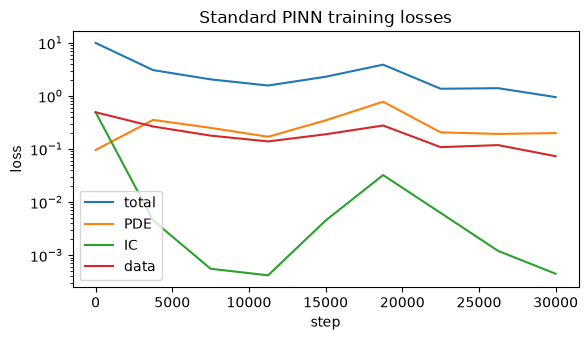

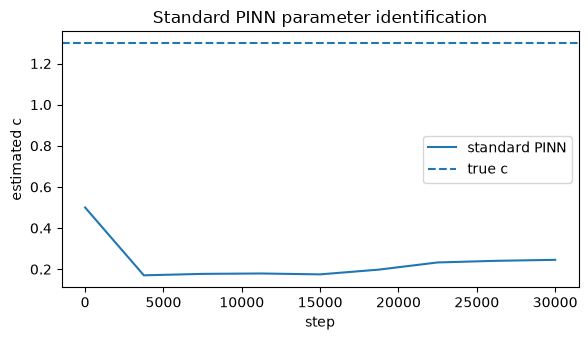


A. Standard PINN
----------------
relative L2 error: 0.7524 -> poor: the oscillatory solution is not learned well.
c_est: 0.245529, c_true: 1.300000, |error|=1.0545 -> poor: c is not reliably identified.
boundary MSE: 1.209e-02
held-out PDE residual MSE: 1.799e+02


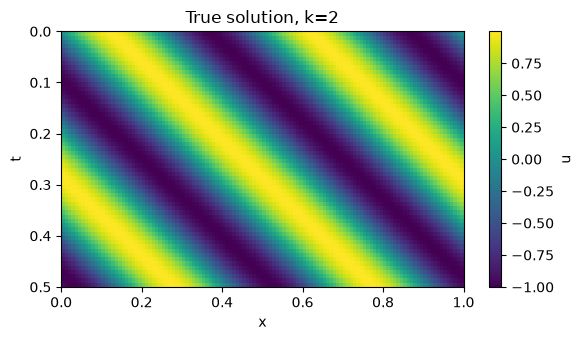

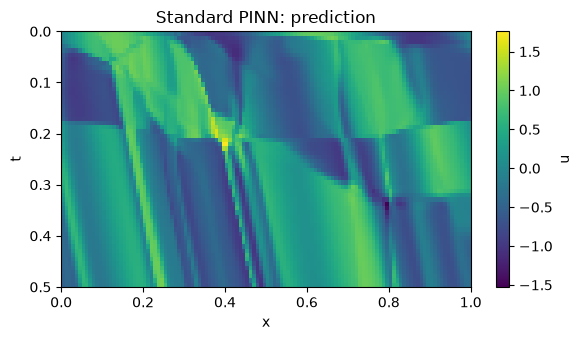

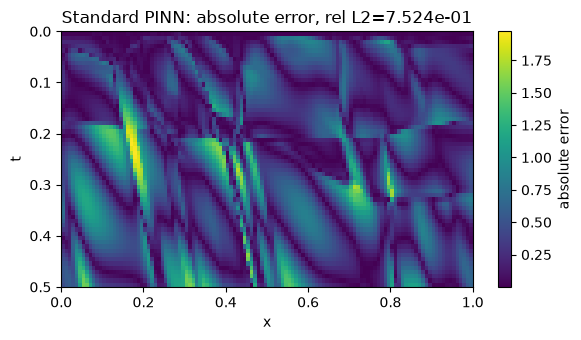

In [9]:
plt.figure(figsize=(6, 3.5))
plt.semilogy(std_h["step"], std_h["total"], label="total")
plt.semilogy(std_h["step"], std_h["pde"], label="PDE")
plt.semilogy(std_h["step"], std_h["ic"], label="IC")
plt.semilogy(std_h["step"], std_h["data"], label="data")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Standard PINN training losses")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(std_h["step"], std_h["c"], label="standard PINN")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Standard PINN parameter identification")
plt.legend()
plt.tight_layout()
plt.show()

std_metrics = evaluate_on_grid(std_state, standard_apply)
print_interpretation("A. Standard PINN", std_metrics)
add_result(RESULTS, "A standard PINN", std_metrics)
plot_solution_comparison(std_metrics, "Standard PINN")

## 8. Diagnostic Analysis: Gradient Norm, Output NTK, and PDE Residual NTK

### 8.1 Gradient norm diagnosis

In a PINN, different loss terms may produce gradients with very different scales. Even if the numerical loss values look similar, the actual gradient driving the parameter update may be dominated by one particular term:

$$
\|\nabla_\theta L_{\mathrm{PDE}}\|,
\quad
\|\nabla_\theta L_{\mathrm{IC}}\|,
\quad
\|\nabla_\theta L_{\mathrm{BC}}\|,
\quad
\|\nabla_\theta L_{\mathrm{data}}\|.
$$

If the gradient of one term is much larger than the others, training may optimize only one constraint while ignoring the data or the initial condition.

Because this is an inverse problem, we also examine the sensitivity of each loss term with respect to $\tilde c$:

$$
\left|\frac{\partial L_j}{\partial \tilde c}\right|,
\qquad c=\operatorname{softplus}(\tilde c).
$$




Standard PINN gradient norms:
  pde  : 1.441e+02
  ic   : 1.102e-01
  bc   : 1.025e+00
  data : 7.234e-01


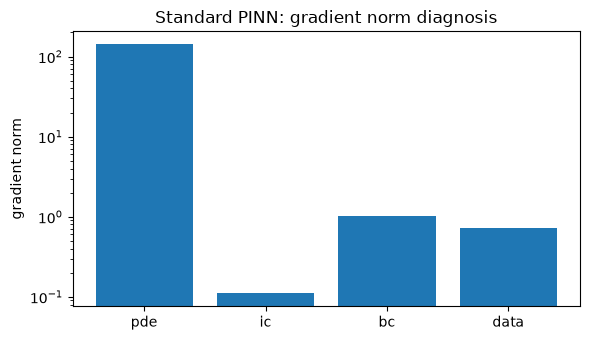


Standard PINN gradients with respect to raw_c, computed by full JAX autodiff:
  pde  : 7.454e-02
  ic   : 0.000e+00
  bc   : 0.000e+00
  data : 0.000e+00
  total: 7.454e-02


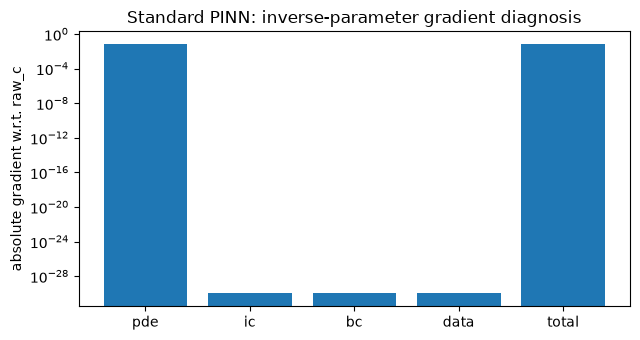

In [10]:
def gradient_norm_diagnosis(state, apply_fn, current_batch=batch):
    names = ["pde", "ic", "bc", "data"]
    norms = {}

    for name in names:
        def component_loss(params):
            temp_state = {"params": params, "raw_c": state["raw_c"]}
            return loss_parts(temp_state, current_batch, apply_fn)[name]

        g = jax.grad(component_loss)(state["params"])
        norms[name] = float(tree_l2_norm(g))

    return norms

std_norms = gradient_norm_diagnosis(std_state, standard_apply)
print("Standard PINN gradient norms:")
for k, v in std_norms.items():
    print(f"  {k:5s}: {v:.3e}")

labels = ["pde", "ic", "bc", "data"]
plt.figure(figsize=(6, 3.5))
plt.bar(labels, [std_norms[k] for k in labels])
plt.yscale("log")
plt.ylabel("gradient norm")
plt.title("Standard PINN: gradient norm diagnosis")
plt.tight_layout()
plt.show()

def inverse_parameter_gradient_diagnosis(state, apply_fn, current_batch=batch, weights=DEFAULT_WEIGHTS):
    """Full autodiff diagnosis for gradients with respect to raw_c.

    For each component L_j, this computes d L_j / d raw_c using jax.grad.
    Network parameters are held fixed.

    Important detail:
    loss_parts(...) returns only the unweighted components:
        pde, ic, bc, data
    It does NOT return "total". Therefore, for name == "total" we explicitly
    rebuild the weighted total loss using the supplied weights.
    """
    names = ["pde", "ic", "bc", "data", "total"]
    grads = {}

    for name in names:
        def component_loss(raw_c):
            temp_state = {"params": state["params"], "raw_c": raw_c}
            parts = loss_parts(temp_state, current_batch, apply_fn)
            if name == "total":
                return (
                    weights["pde"] * parts["pde"]
                    + weights["ic"] * parts["ic"]
                    + weights["bc"] * parts["bc"]
                    + weights["data"] * parts["data"]
                )
            return parts[name]

        g = jax.grad(component_loss)(state["raw_c"])
        grads[name] = float(jnp.abs(g))

    return grads

std_c_grads = inverse_parameter_gradient_diagnosis(std_state, standard_apply)
print("\nStandard PINN gradients with respect to raw_c, computed by full JAX autodiff:")
for k, v in std_c_grads.items():
    print(f"  {k:5s}: {v:.3e}")

labels_c = ["pde", "ic", "bc", "data", "total"]
plt.figure(figsize=(6.5, 3.5))
plt.bar(labels_c, [std_c_grads[k] + 1e-30 for k in labels_c])
plt.yscale("log")
plt.ylabel("absolute gradient w.r.t. raw_c")
plt.title("Standard PINN: inverse-parameter gradient diagnosis")
plt.tight_layout()
plt.show()


The gradient-norm plot shows which loss term dominates the update of the network parameters $\theta$; the inverse-gradient plot shows which loss term actually drives $\tilde c$. Therefore, we should not look only at loss values, because two loss terms with similar numerical values may have completely different effects on parameter updates.


### 8.2 Empirical output NTK

For the neural network $u_\theta$, the empirical output NTK at sampled points $z_i=(x_i,t_i)$ is defined as

$$
K^{(u)}_{ij}
=
\nabla_\theta u_\theta(z_i)^T
\nabla_\theta u_\theta(z_j).
$$

This kernel describes the local training dynamics of the network output $u_\theta$ around the current parameters. If the NTK eigenvalues decay very quickly, then some error directions are learned very slowly, and the training problem may be ill-conditioned.

In the code, `jax.jacrev` is used to compute the Jacobian with respect to the network parameters, and then we construct

$$K^{(u)}=J_uJ_u^T.$$


Computing full empirical output NTK on NTK_N=24 points.
If this cell crashes your kernel, reduce NTK_N or set RUN_NTK=False.
standard initial full NTK:
  largest eigenvalue: 3.627e+02
  smallest positive eigenvalue: 9.702e-06
  condition proxy: 3.739e+07
  effective rank: 1.16
standard trained full NTK:
  largest eigenvalue: 7.208e+03
  smallest positive eigenvalue: 5.016e-01
  condition proxy: 1.437e+04
  effective rank: 2.85


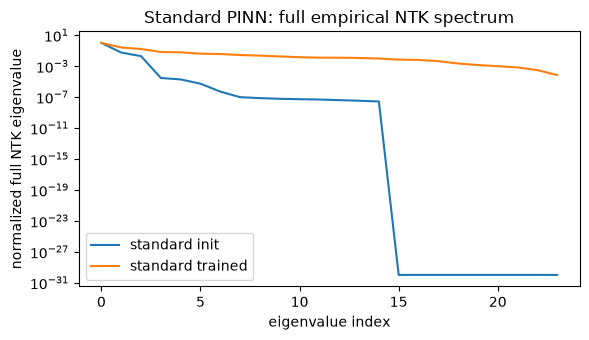

In [11]:
def compute_output_ntk_eigs(state, apply_fn, xt_sample):
    """Full empirical output NTK with respect to all network parameters.

    Given sample points X = {(x_i,t_i)}, define

        K_ij = grad_theta u_theta(x_i,t_i)^T grad_theta u_theta(x_j,t_j).

    This function flattens all MLP parameters, computes the full Jacobian
    J = d f_theta(X) / d theta, and returns the eigenvalues of K = J J^T.

    This is heavier than a last-layer proxy. Keep NTK_N small, for example
    8, 16, or 32, depending on your laptop.
    """
    flat_params, unravel = ravel_pytree(state["params"])

    def f_flat(theta_flat):
        params = unravel(theta_flat)
        return apply_fn(params, xt_sample)  # shape: (N,)

    J = jax.jacrev(f_flat)(flat_params)     # shape: (N, P)
    K = J @ J.T
    K = 0.5 * (K + K.T)
    eigs = jnp.linalg.eigvalsh(K)
    eigs = jnp.sort(jnp.maximum(eigs, 0.0))[::-1]
    return np.array(eigs)

def ntk_summary(eigs, name):
    eigs = np.maximum(eigs, 0.0)
    eigs = eigs[eigs > 1e-20]
    if len(eigs) == 0:
        print(name, "has no positive eigenvalues.")
        return {"largest": np.nan, "smallest": np.nan, "cond_proxy": np.nan, "eff_rank": np.nan}
    eff_rank = (np.sum(eigs)**2) / np.sum(eigs**2)
    cond_proxy = eigs[0] / eigs[-1]
    print(f"{name}:")
    print(f"  largest eigenvalue: {eigs[0]:.3e}")
    print(f"  smallest positive eigenvalue: {eigs[-1]:.3e}")
    print(f"  condition proxy: {cond_proxy:.3e}")
    print(f"  effective rank: {eff_rank:.2f}")
    return {"largest": eigs[0], "smallest": eigs[-1], "cond_proxy": cond_proxy, "eff_rank": eff_rank}

if RUN_NTK:
    xt_ntk = batch["xt_f"][:NTK_N]

    print(f"Computing full empirical output NTK on NTK_N={NTK_N} points.")
    print("If this cell crashes your kernel, reduce NTK_N or set RUN_NTK=False.")

    std_init_eigs = compute_output_ntk_eigs(std_init_state, standard_apply, xt_ntk)
    std_trained_eigs = compute_output_ntk_eigs(std_state, standard_apply, xt_ntk)

    _ = ntk_summary(std_init_eigs, "standard initial full NTK")
    _ = ntk_summary(std_trained_eigs, "standard trained full NTK")

    plt.figure(figsize=(6, 3.5))
    plt.semilogy(std_init_eigs / (std_init_eigs[0] + 1e-30) + 1e-30, label="standard init")
    plt.semilogy(std_trained_eigs / (std_trained_eigs[0] + 1e-30) + 1e-30, label="standard trained")
    plt.xlabel("eigenvalue index")
    plt.ylabel("normalized full NTK eigenvalue")
    plt.title("Standard PINN: full empirical NTK spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("NTK skipped. Set RUN_NTK=True to run this cell.")


The output NTK spectrum describes the local learning directions of $u_\theta$. Directions with large eigenvalues are easier to correct during training, while directions with small eigenvalues are learned slowly. If the spectrum decays quickly, it means that although the network can be trained, some error directions are very difficult to correct. This provides the diagnostic motivation for introducing Fourier features later.


### 8.3 PDE residual NTK: A more direct diagnostic for the physics loss

The output NTK looks at $u_\theta$, but the physics loss in a PINN actually constrains

$$r_\theta=u_t+c u_x.$$

Therefore, we can further define the PDE residual NTK:

$$
K^{(r)}_{ij}
=
\nabla_\theta r_\theta(z_i)^T
\nabla_\theta r_\theta(z_j).
$$

This kernel more directly describes the local learning directions of the PDE residual itself. Intuitively:

- the output NTK asks: which error directions of the network output $u_\theta$ are easy to learn?
- the residual NTK asks: which error directions of the PDE residual $r_\theta$ are easy to reduce?

In an inverse problem, the residual NTK is important because a decreasing PDE loss does not necessarily mean that $c$ is correct. Near a wrong value of $c$, the model may adjust $u_\theta$ so that the residual looks small.


Computing PDE residual NTK on RES_NTK_N=12 collocation points.
If this cell is too heavy, reduce RES_NTK_N to 6 or 8.
standard initial residual NTK, theta only:
  largest eigenvalue: 3.122e+02
  smallest positive eigenvalue: 3.174e-06
  condition proxy: 9.837e+07
  effective rank: 1.01
standard trained residual NTK, theta only:
  largest eigenvalue: 3.396e+04
  smallest positive eigenvalue: 2.557e+02
  condition proxy: 1.328e+02
  effective rank: 5.12
standard initial residual NTK, theta + raw_c:
  largest eigenvalue: 3.122e+02
  smallest positive eigenvalue: 9.382e-06
  condition proxy: 3.327e+07
  effective rank: 1.01
standard trained residual NTK, theta + raw_c:
  largest eigenvalue: 3.398e+04
  smallest positive eigenvalue: 2.571e+02
  condition proxy: 1.322e+02
  effective rank: 5.13


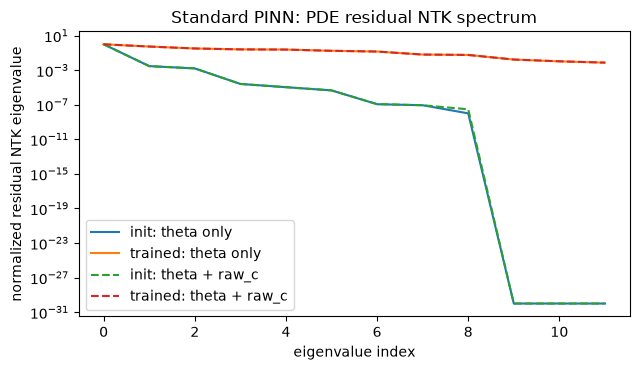


Interpretation:
- A steeper residual-NTK eigenvalue decay means the PDE residual has slow learning directions.
- If theta+raw_c differs strongly from theta-only, the inverse parameter c significantly changes residual dynamics.
- This does not by itself prove c is correct; it only diagnoses local trainability of the residual constraints.


In [12]:
def compute_residual_ntk_eigs(state, apply_fn, xt_sample, include_raw_c=False):
    """Empirical PDE residual NTK on collocation points.

    For residual values

        r_theta(X) = u_t(X) + c u_x(X),

    this computes the kernel

        K_r = J_r J_r^T,

    where J_r is the Jacobian of the residual vector with respect to the
    trainable variables.

    Parameters
    ----------
    include_raw_c : bool
        If False, J_r is taken only with respect to neural-network parameters theta.
        If True, J_r is taken with respect to [theta, raw_c].  This is useful for
        inverse problems because raw_c is also trained.

    Note
    ----
    This is more expensive than output NTK because residuals contain input
    derivatives u_x and u_t, so differentiating residuals with respect to theta
    involves mixed derivatives.  Keep RES_NTK_N small.
    """
    flat_params, unravel = ravel_pytree(state["params"])
    raw_c0 = jnp.asarray(state["raw_c"]).reshape(1)

    def residual_from_params(theta_flat):
        params = unravel(theta_flat)
        temp_state = {"params": params, "raw_c": state["raw_c"]}
        return pde_residual(temp_state, xt_sample, apply_fn)  # shape: (N,)

    if not include_raw_c:
        J = jax.jacrev(residual_from_params)(flat_params)    # shape: (N, P_theta)
    else:
        theta_size = flat_params.shape[0]
        augmented0 = jnp.concatenate([flat_params, raw_c0])

        def residual_from_augmented(augmented):
            theta_flat = augmented[:theta_size]
            raw_c = augmented[theta_size]
            params = unravel(theta_flat)
            temp_state = {"params": params, "raw_c": raw_c}
            return pde_residual(temp_state, xt_sample, apply_fn)  # shape: (N,)

        J = jax.jacrev(residual_from_augmented)(augmented0)  # shape: (N, P_theta + 1)

    K = J @ J.T
    K = 0.5 * (K + K.T)
    eigs = jnp.linalg.eigvalsh(K)
    eigs = jnp.sort(jnp.maximum(eigs, 0.0))[::-1]
    return np.array(eigs)

if RUN_NTK:
    RES_NTK_N = min(12, NTK_N)
    xt_res_ntk = batch["xt_f"][:RES_NTK_N]

    print(f"Computing PDE residual NTK on RES_NTK_N={RES_NTK_N} collocation points.")
    print("If this cell is too heavy, reduce RES_NTK_N to 6 or 8.")

    std_res_init_theta_eigs = compute_residual_ntk_eigs(
        std_init_state, standard_apply, xt_res_ntk, include_raw_c=False
    )
    std_res_trained_theta_eigs = compute_residual_ntk_eigs(
        std_state, standard_apply, xt_res_ntk, include_raw_c=False
    )

    std_res_init_aug_eigs = compute_residual_ntk_eigs(
        std_init_state, standard_apply, xt_res_ntk, include_raw_c=True
    )
    std_res_trained_aug_eigs = compute_residual_ntk_eigs(
        std_state, standard_apply, xt_res_ntk, include_raw_c=True
    )

    _ = ntk_summary(std_res_init_theta_eigs, "standard initial residual NTK, theta only")
    _ = ntk_summary(std_res_trained_theta_eigs, "standard trained residual NTK, theta only")
    _ = ntk_summary(std_res_init_aug_eigs, "standard initial residual NTK, theta + raw_c")
    _ = ntk_summary(std_res_trained_aug_eigs, "standard trained residual NTK, theta + raw_c")

    plt.figure(figsize=(6.5, 3.8))
    plt.semilogy(
        std_res_init_theta_eigs / (std_res_init_theta_eigs[0] + 1e-30) + 1e-30,
        label="init: theta only",
    )
    plt.semilogy(
        std_res_trained_theta_eigs / (std_res_trained_theta_eigs[0] + 1e-30) + 1e-30,
        label="trained: theta only",
    )
    plt.semilogy(
        std_res_init_aug_eigs / (std_res_init_aug_eigs[0] + 1e-30) + 1e-30,
        linestyle="--",
        label="init: theta + raw_c",
    )
    plt.semilogy(
        std_res_trained_aug_eigs / (std_res_trained_aug_eigs[0] + 1e-30) + 1e-30,
        linestyle="--",
        label="trained: theta + raw_c",
    )
    plt.xlabel("eigenvalue index")
    plt.ylabel("normalized residual NTK eigenvalue")
    plt.title("Standard PINN: PDE residual NTK spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print("- A steeper residual-NTK eigenvalue decay means the PDE residual has slow learning directions.")
    print("- If theta+raw_c differs strongly from theta-only, the inverse parameter c significantly changes residual dynamics.")
    print("- This does not by itself prove c is correct; it only diagnoses local trainability of the residual constraints.")
else:
    print("Residual NTK skipped because RUN_NTK=False.")


## 9. Representation Improvement: Fourier-Feature PINN

If the baseline does not reconstruct the oscillatory wave well, a natural suspicion is that an ordinary MLP cannot easily represent the function. Therefore, this section introduces Fourier features, which first map the input into sine/cosine features.

This method mainly answers:

> Is the failure of the standard PINN caused by insufficient representation ability?

For $k=2$, Fourier features may be less necessary than in the $k=8$ case. If Fourier features still improve solution reconstruction or the NTK spectrum, then representation ability is part of the story. If $c$ remains inaccurate, then representation ability is not the only bottleneck.


In [13]:
try:
    jax.clear_caches()
except Exception:
    pass

fourier_state, fourier_hist, fourier_init_state = train_pinn(
    model_name="C Fourier-feature PINN",
    apply_fn=fourier_apply,
    input_dim=FOURIER_INPUT_DIM,
    seed=1,
    weights=DEFAULT_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
)

fourier_h = history_to_arrays(fourier_hist)

[C Fourier-feature PINN] step=    1 loss=5.324e+01 pde=4.13e+01 ic=6.42e-01 bc=1.58e-02 data=5.45e-01 c=0.500000
[C Fourier-feature PINN] step= 3750 loss=1.249e-02 pde=3.74e-03 ic=8.10e-05 bc=1.65e-04 data=7.78e-04 c=1.186977
[C Fourier-feature PINN] step= 7500 loss=2.336e-03 pde=7.05e-04 ic=1.40e-05 bc=6.50e-05 data=1.43e-04 c=1.250130
[C Fourier-feature PINN] step=11250 loss=1.838e-03 pde=1.21e-03 ic=7.58e-06 bc=2.64e-05 data=5.25e-05 c=1.270532
[C Fourier-feature PINN] step=15000 loss=1.280e-03 pde=9.26e-04 ic=6.15e-06 bc=1.34e-05 data=2.80e-05 c=1.280019
[C Fourier-feature PINN] step=18750 loss=2.964e-03 pde=2.56e-03 ic=1.80e-05 bc=6.99e-06 data=2.18e-05 c=1.285515
[C Fourier-feature PINN] step=22500 loss=2.833e-03 pde=2.63e-03 ic=4.51e-06 bc=5.01e-06 data=1.58e-05 c=1.288235
[C Fourier-feature PINN] step=26250 loss=1.031e-03 pde=8.68e-04 ic=5.20e-06 bc=3.28e-06 data=1.08e-05 c=1.290189
[C Fourier-feature PINN] step=30000 loss=3.841e-04 pde=2.98e-04 ic=1.62e-06 bc=3.28e-06 data=6.6

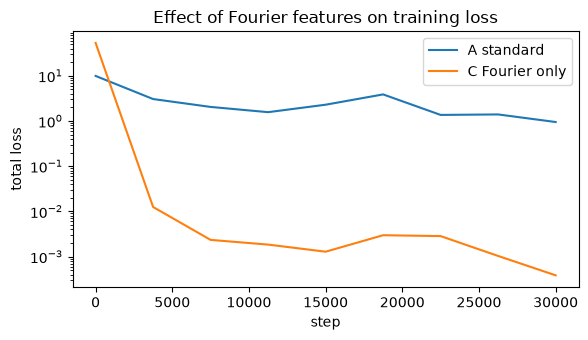

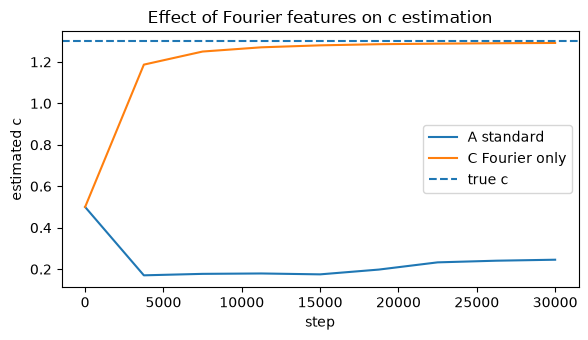


C. Fourier-feature PINN only
----------------------------
relative L2 error: 0.0084 -> good: the solution is learned reasonably well.
c_est: 1.291561, c_true: 1.300000, |error|=0.0084 -> good: c is accurately identified.
boundary MSE: 5.627e-06
held-out PDE residual MSE: 1.571e-01


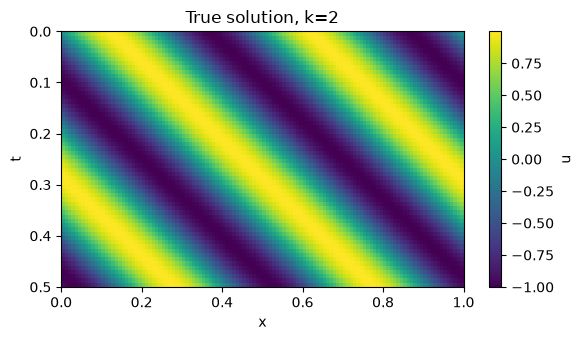

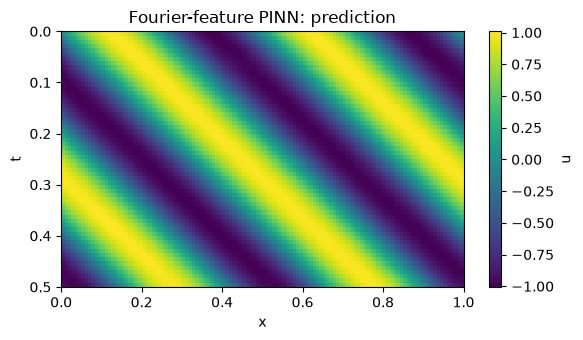

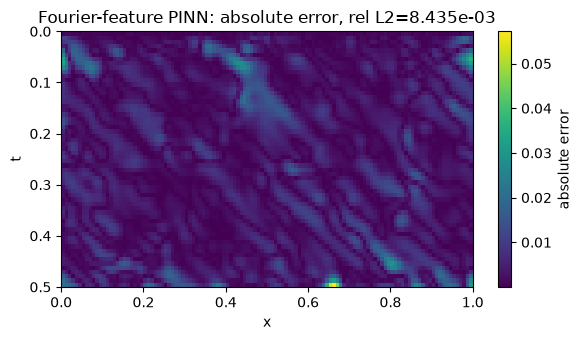

In [14]:
plt.figure(figsize=(6, 3.5))
plt.semilogy(std_h["step"], std_h["total"], label="A standard")
plt.semilogy(fourier_h["step"], fourier_h["total"], label="C Fourier only")
plt.xlabel("step")
plt.ylabel("total loss")
plt.title("Effect of Fourier features on training loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(std_h["step"], std_h["c"], label="A standard")
plt.plot(fourier_h["step"], fourier_h["c"], label="C Fourier only")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Effect of Fourier features on c estimation")
plt.legend()
plt.tight_layout()
plt.show()

fourier_metrics = evaluate_on_grid(fourier_state, fourier_apply)
print_interpretation("C. Fourier-feature PINN only", fourier_metrics)
add_result(RESULTS, "C Fourier only", fourier_metrics, baseline=std_metrics)
plot_solution_comparison(fourier_metrics, "Fourier-feature PINN")

### 9.1 NTK Comparison Motivated by the Results: Standard vs Fourier

Here we compare the NTK spectra of the standard PINN and the Fourier-feature PINN.

> Fourier features change the input representation, which changes the network Jacobian at the sampled points and therefore changes the spectrum of the empirical NTK.

If the Fourier spectrum is flatter or has more effective eigenvalues, then it improves local training conditioning. However, if $c$ is still wrong, then inverse-parameter identification has an additional difficulty.


Fourier initial full NTK:
  largest eigenvalue: 2.331e+02
  smallest positive eigenvalue: 7.757e-01
  condition proxy: 3.005e+02
  effective rank: 8.45
Fourier trained full NTK:
  largest eigenvalue: 4.143e+02
  smallest positive eigenvalue: 1.582e+00
  condition proxy: 2.619e+02
  effective rank: 6.08


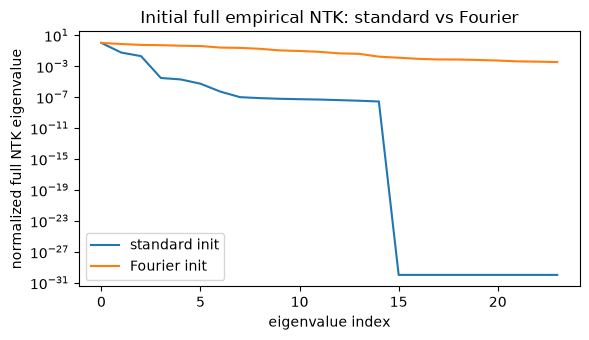

In [15]:
if RUN_NTK:
    fourier_init_eigs = compute_output_ntk_eigs(fourier_init_state, fourier_apply, xt_ntk)
    fourier_trained_eigs = compute_output_ntk_eigs(fourier_state, fourier_apply, xt_ntk)

    _ = ntk_summary(fourier_init_eigs, "Fourier initial full NTK")
    _ = ntk_summary(fourier_trained_eigs, "Fourier trained full NTK")

    plt.figure(figsize=(6, 3.5))
    plt.semilogy(std_init_eigs / (std_init_eigs[0] + 1e-30) + 1e-30, label="standard init")
    plt.semilogy(fourier_init_eigs / (fourier_init_eigs[0] + 1e-30) + 1e-30, label="Fourier init")
    plt.xlabel("eigenvalue index")
    plt.ylabel("normalized full NTK eigenvalue")
    plt.title("Initial full empirical NTK: standard vs Fourier")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("NTK skipped.")


## 10. Constraint Improvement: Hard Periodic Boundary Embedding

The solution of the advection equation is periodic in the $x$ direction. A soft-boundary PINN approximates the periodic boundary condition by penalizing

$$u_\theta(0,t)-u_\theta(1,t)$$

in the loss. Another approach is to directly build periodicity into the input features.

The hard-periodic embedding represents $x$ using

$$\sin(2\pi f_jx),\quad \cos(2\pi f_jx),$$

so the features at $x=0$ and $x=1$ are exactly identical. Therefore, the model satisfies the periodic boundary condition by construction.

This step mainly tests: **if the boundary condition is already structurally satisfied, can $c$ be learned correctly?** If the answer is no, then the main bottleneck is not the boundary condition, but the landscape of the inverse parameter.


In [16]:
try:
    jax.clear_caches()
except Exception:
    pass

hard_state, hard_hist, hard_init_state = train_pinn(
    model_name="D hard periodic boundary",
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    seed=2,
    weights=HARD_BC_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
)

hard_h = history_to_arrays(hard_hist)

[D hard periodic boundary] step=    1 loss=4.943e+01 pde=3.56e+01 ic=7.89e-01 bc=1.85e-13 data=5.91e-01 c=0.500000
[D hard periodic boundary] step= 3750 loss=3.114e-02 pde=7.57e-03 ic=1.20e-04 bc=1.48e-13 data=2.24e-03 c=0.994977
[D hard periodic boundary] step= 7500 loss=4.448e-03 pde=6.21e-04 ic=2.85e-05 bc=1.18e-13 data=3.54e-04 c=1.129209
[D hard periodic boundary] step=11250 loss=5.475e-03 pde=4.18e-03 ic=1.52e-05 bc=9.60e-14 data=1.14e-04 c=1.189535
[D hard periodic boundary] step=15000 loss=6.820e-03 pde=6.14e-03 ic=1.17e-05 bc=9.43e-14 data=5.66e-05 c=1.226063
[D hard periodic boundary] step=18750 loss=2.094e-02 pde=2.00e-02 ic=4.97e-05 bc=9.79e-14 data=4.57e-05 c=1.247101
[D hard periodic boundary] step=22500 loss=2.115e-03 pde=1.89e-03 ic=3.04e-06 bc=1.03e-13 data=1.95e-05 c=1.259609
[D hard periodic boundary] step=26250 loss=1.454e-03 pde=1.30e-03 ic=2.84e-06 bc=8.45e-14 data=1.26e-05 c=1.267406
[D hard periodic boundary] step=30000 loss=2.196e-02 pde=2.09e-02 ic=3.61e-05 bc

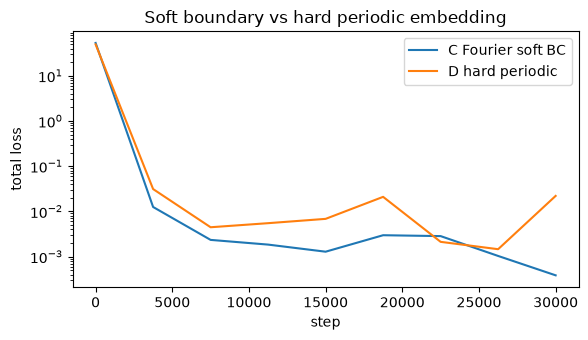

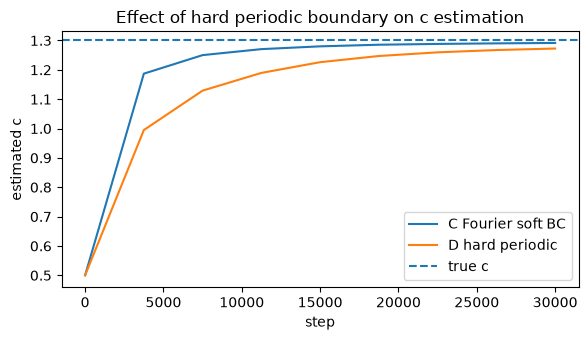


D. Hard periodic boundary
-------------------------
relative L2 error: 0.0240 -> good: the solution is learned reasonably well.
c_est: 1.272590, c_true: 1.300000, |error|=0.0274 -> good: c is accurately identified.
boundary MSE: 9.247e-14
held-out PDE residual MSE: 9.757e-01


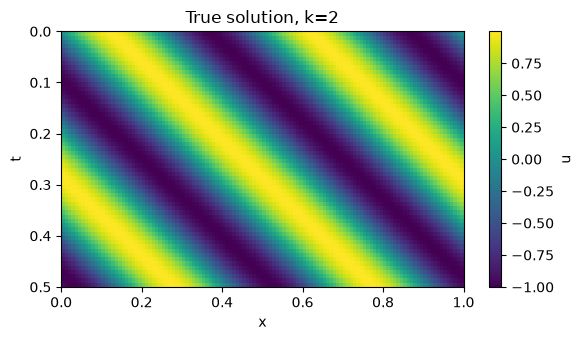

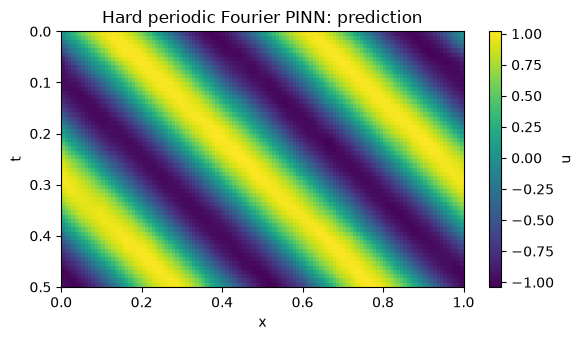

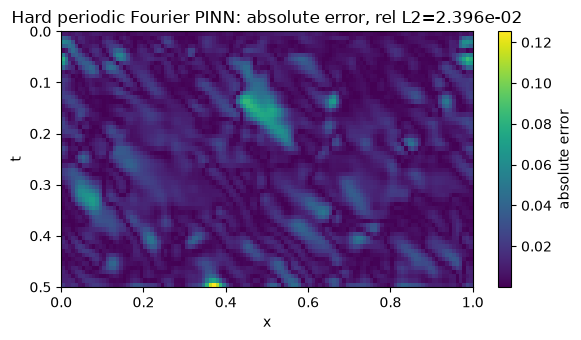

In [17]:
plt.figure(figsize=(6, 3.5))
plt.semilogy(fourier_h["step"], fourier_h["total"], label="C Fourier soft BC")
plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic")
plt.xlabel("step")
plt.ylabel("total loss")
plt.title("Soft boundary vs hard periodic embedding")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(fourier_h["step"], fourier_h["c"], label="C Fourier soft BC")
plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Effect of hard periodic boundary on c estimation")
plt.legend()
plt.tight_layout()
plt.show()

hard_metrics = evaluate_on_grid(hard_state, hard_periodic_apply)
print_interpretation("D. Hard periodic boundary", hard_metrics)
add_result(RESULTS, "D hard periodic", hard_metrics, baseline=fourier_metrics)
plot_solution_comparison(hard_metrics, "Hard periodic Fourier PINN")

## 11. Optimization Check: Giving the Inverse-Problem Parameter $c$ a Larger Learning Rate

If $c$ is not learned well, a simple suspicion is that the learning rate for $c$ is too small. Therefore, we increase $\eta_c$ and check whether $c$ can approach the true value faster.

> Is $c$ wrong because it updates too slowly, or because it is attracted to a wrong loss basin?

If increasing the learning rate for $c$ still cannot bring it close to $1.30$, or even makes training more unstable, then the problem is not merely that the step size is too small. It is more likely caused by the inverse-problem landscape or misleading early-stage residual gradients.


In [18]:
try:
    jax.clear_caches()
except Exception:
    pass

hard_fastc_state, hard_fastc_hist, hard_fastc_init_state = train_pinn(
    model_name="E hard periodic + faster c",
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    seed=2,  # same seed as D for fairer comparison
    weights=HARD_BC_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=3e-3,
)

hard_fastc_h = history_to_arrays(hard_fastc_hist)

[E hard periodic + faster c] step=    1 loss=4.943e+01 pde=3.56e+01 ic=7.89e-01 bc=1.85e-13 data=5.91e-01 c=0.500000
[E hard periodic + faster c] step= 3750 loss=2.780e-02 pde=2.24e-02 ic=1.16e-04 bc=1.10e-13 data=4.20e-04 c=1.231013
[E hard periodic + faster c] step= 7500 loss=2.019e-03 pde=1.13e-03 ic=1.15e-05 bc=1.07e-13 data=7.79e-05 c=1.269282
[E hard periodic + faster c] step=11250 loss=4.107e-02 pde=3.73e-02 ic=2.66e-04 bc=9.49e-14 data=1.10e-04 c=1.281456
[E hard periodic + faster c] step=15000 loss=8.678e-03 pde=8.38e-03 ic=5.53e-06 bc=8.83e-14 data=2.38e-05 c=1.286492
[E hard periodic + faster c] step=18750 loss=1.344e-03 pde=1.22e-03 ic=1.89e-06 bc=8.71e-14 data=1.04e-05 c=1.289095
[E hard periodic + faster c] step=22500 loss=1.424e-03 pde=1.27e-03 ic=5.29e-06 bc=8.75e-14 data=1.02e-05 c=1.290820
[E hard periodic + faster c] step=26250 loss=8.726e-03 pde=8.25e-03 ic=2.01e-05 bc=8.97e-14 data=2.75e-05 c=1.292048
[E hard periodic + faster c] step=30000 loss=1.010e-02 pde=9.50e

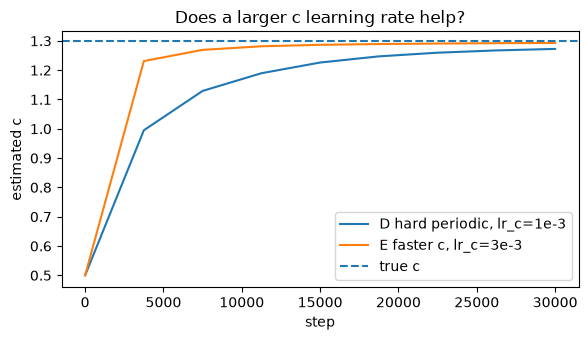


E. Hard periodic + faster c
---------------------------
relative L2 error: 0.0110 -> good: the solution is learned reasonably well.
c_est: 1.293147, c_true: 1.300000, |error|=0.0069 -> good: c is accurately identified.
boundary MSE: 1.015e-13
held-out PDE residual MSE: 1.250e-01


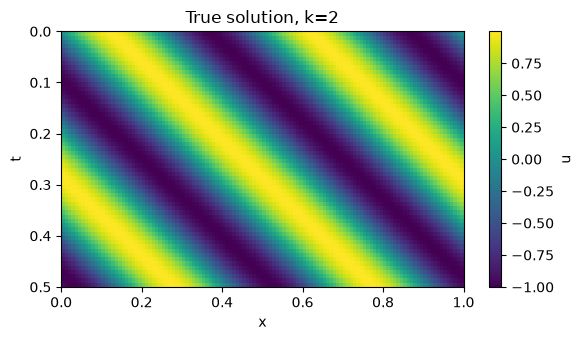

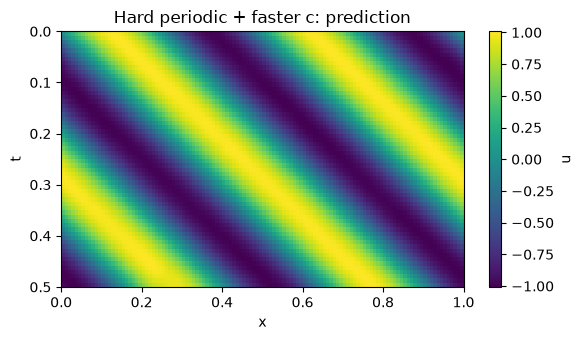

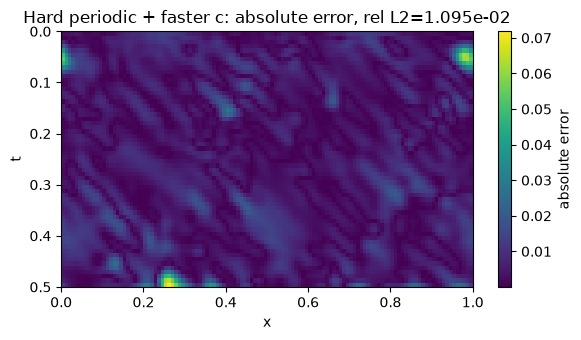

In [19]:
plt.figure(figsize=(6, 3.5))
plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic, lr_c=1e-3")
plt.plot(hard_fastc_h["step"], hard_fastc_h["c"], label="E faster c, lr_c=3e-3")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Does a larger c learning rate help?")
plt.legend()
plt.tight_layout()
plt.show()

hard_fastc_metrics = evaluate_on_grid(hard_fastc_state, hard_periodic_apply)
print_interpretation("E. Hard periodic + faster c", hard_fastc_metrics)
add_result(RESULTS, "E hard periodic + faster c", hard_fastc_metrics, baseline=hard_metrics)
plot_solution_comparison(hard_fastc_metrics, "Hard periodic + faster c")

## 12. Inverse-Problem Landscape Analysis: Characteristic Baseline

To temporarily remove the neural-network factor, this section analyzes only $c$ itself. The characteristic formula for the advection equation gives

$$u(x,t;c)=u_0(x-ct).$$

Therefore, we can define a characteristic loss that depends only on $c$:

$$
L_{\mathrm{char}}(c)
=
\frac1N\sum_i
\left|
\sin(2\pi k(x_i-c t_i))-u_i
\right|^2.
$$

The meaning of this experiment is that even without training a neural network, the loss landscape of $c$ alone may contain local basins. For $k=2$, the phase periodicity is weaker than in the $k=8$ case, so the characteristic landscape should usually be smoother and easier to optimize.

This section is therefore used as a frequency ablation: if the $k=2$ landscape is much cleaner than the $k=8$ landscape, then the original difficulty is genuinely related to the high-frequency phase term.


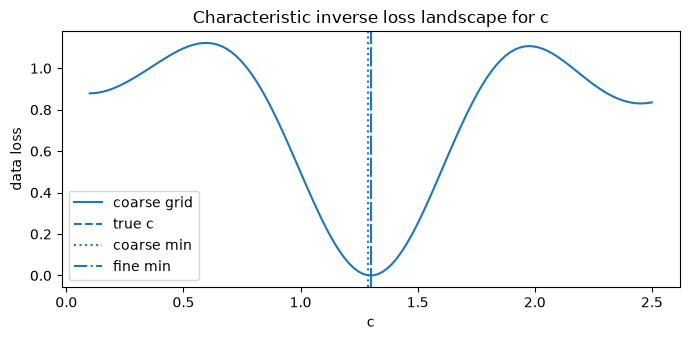

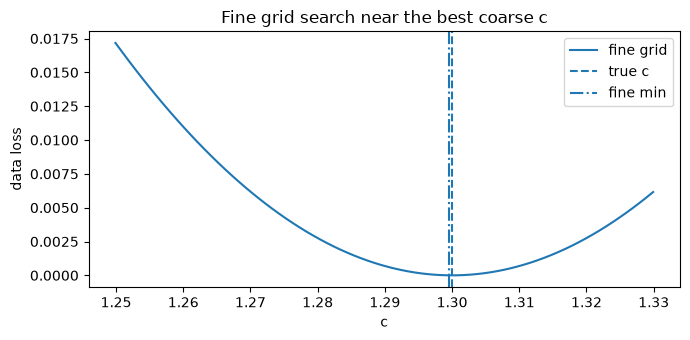

Grid-search minimum:
  c_coarse_min = 1.2899160385131836
  c_fine_min   = 1.2995362281799316
  fine loss    = 1.4821969216427533e-06
  true c       = 1.3
  |c_init-c_true| = 0.0004637718200684038


In [20]:
try:
    jax.clear_caches()
except Exception:
    pass

def characteristic_predict(c, xt):
    x = xt[:, 0]
    t = xt[:, 1]
    return jnp.sin(2.0 * jnp.pi * K_FREQ * (x - c * t))

def characteristic_loss(c):
    pred = characteristic_predict(c, batch["xt_data"])
    return jnp.mean((pred - batch["y_data"])**2)

# First, a coarse grid over a wide range.
c_grid_coarse = jnp.linspace(C_GRID_MIN, C_GRID_MAX, C_GRID_COARSE_N)
loss_grid_coarse = jax.vmap(characteristic_loss)(c_grid_coarse)
idx_coarse = int(jnp.argmin(loss_grid_coarse))
c_coarse_min = float(c_grid_coarse[idx_coarse])

# Then, a fine grid around the best coarse value.
fine_left = max(C_GRID_MIN, c_coarse_min - C_GRID_FINE_RADIUS)
fine_right = min(C_GRID_MAX, c_coarse_min + C_GRID_FINE_RADIUS)
c_grid_fine = jnp.linspace(fine_left, fine_right, C_GRID_FINE_N)
loss_grid_fine = jax.vmap(characteristic_loss)(c_grid_fine)
idx_fine = int(jnp.argmin(loss_grid_fine))
c_fine_min = float(c_grid_fine[idx_fine])

plt.figure(figsize=(7, 3.5))
plt.plot(np.array(c_grid_coarse), np.array(loss_grid_coarse), label="coarse grid")
plt.axvline(C_TRUE, linestyle="--", label="true c")
plt.axvline(c_coarse_min, linestyle=":", label="coarse min")
plt.axvline(c_fine_min, linestyle="-.", label="fine min")
plt.xlabel("c")
plt.ylabel("data loss")
plt.title("Characteristic inverse loss landscape for c")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(np.array(c_grid_fine), np.array(loss_grid_fine), label="fine grid")
plt.axvline(C_TRUE, linestyle="--", label="true c")
plt.axvline(c_fine_min, linestyle="-.", label="fine min")
plt.xlabel("c")
plt.ylabel("data loss")
plt.title("Fine grid search near the best coarse c")
plt.legend()
plt.tight_layout()
plt.show()

c_grid_init = c_fine_min
print("Grid-search minimum:")
print("  c_coarse_min =", c_coarse_min)
print("  c_fine_min   =", c_grid_init)
print("  fine loss    =", float(loss_grid_fine[idx_fine]))
print("  true c       =", C_TRUE)
print("  |c_init-c_true| =", abs(c_grid_init - C_TRUE))


Here we first remove the neural network and change only $c$. Since the data come from a sinusoidal transported wave, different values of $c$ may still produce similar phases at sparse points. However, with $k=2$ this ambiguity should be milder than with $k=8$. If joint training becomes more successful in this notebook, that is evidence that the frequency controls the difficulty of identifying $c$.


### 12.1 From the Landscape to an Inverse-Specific Method

The characteristic landscape tells us that if the one-dimensional loss in $c$ is already nonconvex, then directly training $c$ together with the network parameters is likely to fail.

Therefore, the next step should not be merely increasing the number of training iterations. Instead, we should start $c$ from a more reasonable position. In other words, we need an initialization method designed specifically for the inverse-problem parameter, rather than relying only on random PINN initialization.


## 13. Main Method: Grid-Initialized Two-Stage Training

If the characteristic loss in $c$ is nonconvex, then starting from an arbitrary initial value such as $c_0=0.5$ and directly performing joint training can easily enter a wrong basin. Therefore, this section uses a two-step strategy.

### Step 1: Use grid search to initialize $c$

First, search the characteristic loss on a one-dimensional $c$-grid:

$$c_0=\arg\min_c L_{\mathrm{char}}(c).$$

This step does not train the neural network. It only uses the characteristic-line structure of the advection equation to find a better initial value for the parameter.

### Step 2: Two-stage PINN training

Even if $c_0$ is good, we should not allow $c$ and the network to make large joint updates from the very beginning. During early training, $u_\theta$ is still poor, so the PDE residual

$$r_\theta=u_t+c u_x$$

may provide misleading gradients for $c$. Therefore, we use two-stage training:

**Stage 1: Fix $c=c_0$ and train only the network parameters**

$$
\min_\theta
\left(
\lambda_f L_{\mathrm{PDE}}(\theta,c_0)
+\lambda_i L_{\mathrm{IC}}(\theta)
+\lambda_d L_{\mathrm{data}}(\theta)
\right).
$$

**Stage 2: Unfreeze $c$ and fine-tune it with a smaller learning rate**

$$
\min_{\theta,c}
\left(
\lambda_f L_{\mathrm{PDE}}(\theta,c)
+\lambda_i L_{\mathrm{IC}}(\theta)
+\lambda_d L_{\mathrm{data}}(\theta)
\right).
$$

The key judgment in this section is: if grid-initialized two-stage training clearly reduces $|c-c^*|$, then inverse-parameter initialization is a critical factor.


In [21]:
try:
    jax.clear_caches()
except Exception:
    pass

def train_pinn_freeze_c(
    model_name,
    apply_fn,
    input_dim,
    seed,
    c_init,
    weights=HARD_BC_WEIGHTS,
    n_steps=GRID_STAGE1_STEPS,
    lr_params=GRID_STAGE1_LR_PARAMS,
    current_batch=batch,
):
    """Train only network parameters while keeping raw_c fixed.

    This is useful for inverse problems: the network first learns a reasonable
    solution representation before the inverse parameter c is allowed to move.
    """
    state, opt_state = init_state_and_optimizer(input_dim, seed, c_init=c_init)
    opt_params = opt_state["params"]
    loss_fn = make_loss_fn(apply_fn, weights)

    @jax.jit
    def train_step_params_only(state, opt_params, current_batch):
        def loss_on_params(params):
            temp_state = {"params": params, "raw_c": state["raw_c"]}
            return loss_fn(temp_state, current_batch)

        (loss_value, parts), grad_params = jax.value_and_grad(
            loss_on_params, has_aux=True
        )(state["params"])

        new_params, new_opt_params = adam_update(
            state["params"], grad_params, opt_params, lr_params
        )
        new_state = {"params": new_params, "raw_c": state["raw_c"]}
        return new_state, new_opt_params, loss_value, parts

    history = []
    start = time.time()
    for step in range(1, n_steps + 1):
        state, opt_params, loss_value, parts = train_step_params_only(
            state, opt_params, current_batch
        )

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] stage1 step={step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c(fixed)={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] stage 1 finished in {elapsed:.1f} seconds.")
    return state, history

def continue_train_pinn(
    model_name,
    state,
    apply_fn,
    weights=HARD_BC_WEIGHTS,
    n_steps=GRID_STAGE2_STEPS,
    lr_params=GRID_STAGE2_LR_PARAMS,
    lr_c=GRID_STAGE2_LR_C,
    current_batch=batch,
    step_offset=0,
):
    """Continue training from an existing state, updating both theta and c."""
    opt_state = {"params": adam_init(state["params"]), "raw_c": adam_init(state["raw_c"])}
    loss_fn = make_loss_fn(apply_fn, weights)
    train_step = make_train_step(loss_fn, lr_params, lr_c)

    history = []
    start = time.time()
    for local_step in range(1, n_steps + 1):
        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)
        global_step = step_offset + local_step

        if local_step == 1 or local_step % PRINT_EVERY == 0 or local_step == n_steps:
            rec = {
                "step": global_step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] stage2 step={global_step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] stage 2 finished in {elapsed:.1f} seconds.")
    return state, history

if RUN_GRID_INIT_PINN:
    print("Using grid-search initialization for two-stage PINN:")
    print("  c_init from characteristic coarse/fine grid =", c_grid_init)
    print("  true c =", C_TRUE)
    print("  stage 1 steps:", GRID_STAGE1_STEPS, "fixed c")
    print("  stage 2 steps:", GRID_STAGE2_STEPS, "lr_c =", GRID_STAGE2_LR_C)

    grid_stage1_state, grid_stage1_hist = train_pinn_freeze_c(
        model_name="I grid-initialized hard-periodic PINN",
        apply_fn=hard_periodic_apply,
        input_dim=HARD_PERIODIC_INPUT_DIM,
        seed=2,
        c_init=c_grid_init,
        weights=HARD_BC_WEIGHTS,
        n_steps=GRID_STAGE1_STEPS,
        lr_params=GRID_STAGE1_LR_PARAMS,
    )

    grid_init_state, grid_stage2_hist = continue_train_pinn(
        model_name="I grid-initialized hard-periodic PINN",
        state=grid_stage1_state,
        apply_fn=hard_periodic_apply,
        weights=HARD_BC_WEIGHTS,
        n_steps=GRID_STAGE2_STEPS,
        lr_params=GRID_STAGE2_LR_PARAMS,
        lr_c=GRID_STAGE2_LR_C,
        current_batch=batch,
        step_offset=GRID_STAGE1_STEPS,
    )

    grid_init_hist = grid_stage1_hist + grid_stage2_hist
    grid_init_h = history_to_arrays(grid_init_hist)
else:
    print("Grid-initialized PINN skipped. Set RUN_GRID_INIT_PINN=True to run this part.")

Using grid-search initialization for two-stage PINN:
  c_init from characteristic coarse/fine grid = 1.2995362281799316
  true c = 1.3
  stage 1 steps: 21000 fixed c
  stage 2 steps: 9000 lr_c = 0.0002
[I grid-initialized hard-periodic PINN] stage1 step=    1 loss=1.519e+02 pde=1.38e+02 ic=7.89e-01 data=5.91e-01 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step= 3750 loss=2.938e-02 pde=2.86e-02 ic=3.29e-05 data=4.18e-05 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step= 7500 loss=2.225e-03 pde=2.03e-03 ic=4.89e-06 data=1.46e-05 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step=11250 loss=1.305e-03 pde=1.17e-03 ic=5.66e-06 data=7.97e-06 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step=15000 loss=1.420e-03 pde=1.29e-03 ic=6.59e-06 data=6.46e-06 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step=18750 loss=6.729e-03 pde=6.46e-03 ic=8.45e-06 data=1.84e-05 c(fixed)=1.299536
[I grid-initialize

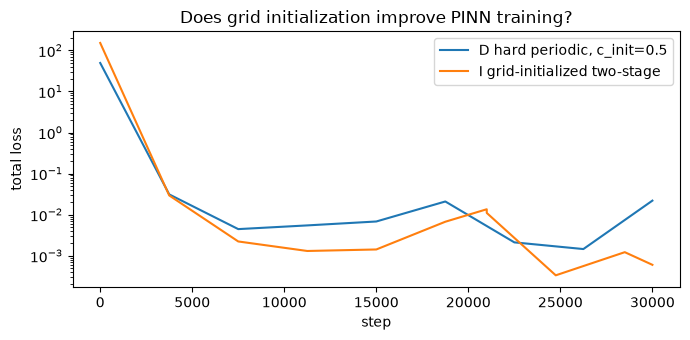

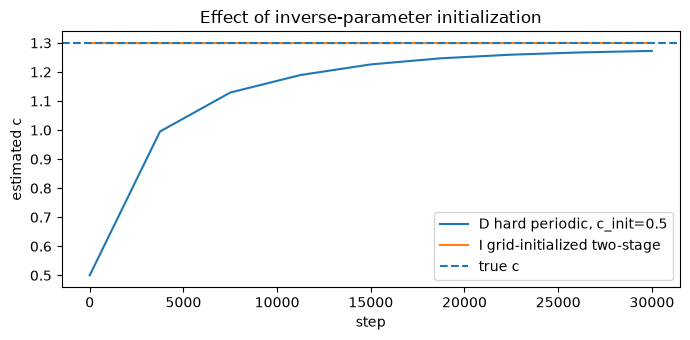


I. Grid-initialized two-stage hard-periodic PINN
------------------------------------------------
relative L2 error: 0.0031 -> good: the solution is learned reasonably well.
c_est: 1.299896, c_true: 1.300000, |error|=0.0001 -> good: c is accurately identified.
boundary MSE: 7.372e-14
held-out PDE residual MSE: 7.082e-03


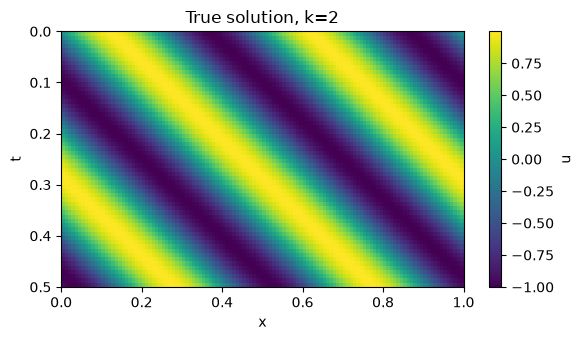

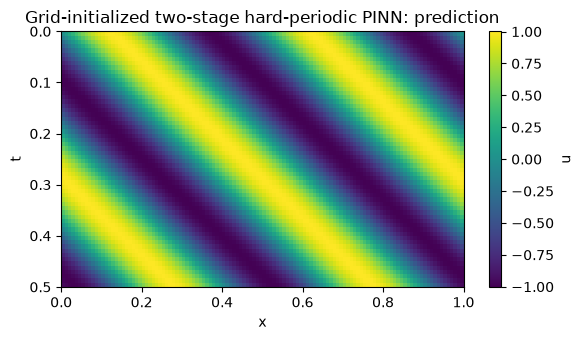

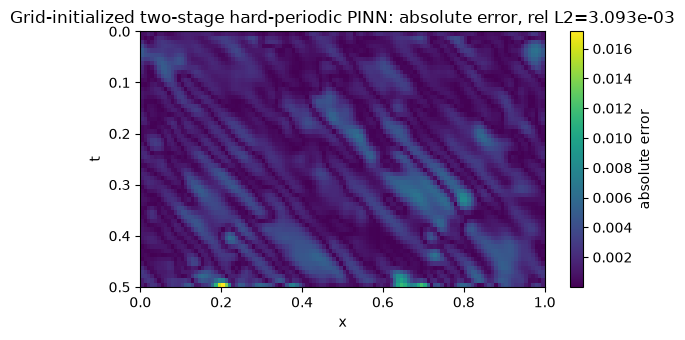

In [22]:
if RUN_GRID_INIT_PINN:
    plt.figure(figsize=(7, 3.5))
    plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic, c_init=0.5")
    plt.semilogy(grid_init_h["step"], grid_init_h["total"], label="I grid-initialized two-stage")
    plt.xlabel("step")
    plt.ylabel("total loss")
    plt.title("Does grid initialization improve PINN training?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic, c_init=0.5")
    plt.plot(grid_init_h["step"], grid_init_h["c"], label="I grid-initialized two-stage")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Effect of inverse-parameter initialization")
    plt.legend()
    plt.tight_layout()
    plt.show()

    grid_init_metrics = evaluate_on_grid(grid_init_state, hard_periodic_apply)
    print_interpretation("I. Grid-initialized two-stage hard-periodic PINN", grid_init_metrics)
    add_result(RESULTS, "I grid-init two-stage", grid_init_metrics, baseline=hard_metrics)
    plot_solution_comparison(grid_init_metrics, "Grid-initialized two-stage hard-periodic PINN")


This method is inverse-specific: it first uses the characteristic formula to place $c$ near a reasonable basin, then fixes $c$ while training the network, and only finally fine-tunes $c$. It separates "fitting the solution field" from "identifying the parameter", avoiding wrong gradients for $c$ from an inaccurate early-stage $u_\theta$.


## 14. Additional Methods After Grid Initialization: Keep Only the Useful Post-Grid Comparisons

After checking the learned values on the characteristic loss landscape, the post-grid experiments whose estimated values of $c$ were below 1 were removed, except for the standard PINN baseline. This keeps the notebook focused on the methods that either recovered $c$ close to the true value or remain useful as diagnostic controls.

### 14.1 Method F: Loss curriculum

In ordinary joint training, the PDE residual may dominate too early. We therefore start with a weak PDE loss and gradually increase it:

$$
\lambda_f=0.01 \quad\rightarrow\quad 0.1 \quad\rightarrow\quad 1.
$$

The idea is to let data / IC / BC shape the solution field first, and only later enforce the PDE strongly. If this helps, the original failure is related to loss imbalance and early-stage residual gradients.

### 14.2 Method G: Adaptive gradient-balanced loss weighting

Instead of manually fixing all loss weights, this method periodically measures the gradient norms of the different unweighted loss components and adjusts their weights so that no single term dominates the update. This tests whether the inverse parameter fails because of gradient imbalance between PDE, IC, BC and data losses.

### 14.3 Method I: Residual-based adaptive refinement (RAR)

RAR adds collocation points where the current PDE residual is large. This is kept as an optional diagnostic. If RAR improves residual error but not $c$, then collocation-point placement is not the main bottleneck of the inverse-parameter problem.


In [23]:
try:
    jax.clear_caches()
except Exception:
    pass

# Extra experiments after grid initialization.
# Kept methods:
#   Method F: loss curriculum
#   Method G: adaptive gradient-balanced weights
#   Method I: RAR, optional because it can be slow
RUN_LOSS_CURRICULUM_EXPERIMENT = True
RUN_ADAPTIVE_GRAD_WEIGHTING = True
RUN_RAR_EXPERIMENT = False   # RAR is useful but can be slow; turn on for a longer run.

# Method F settings
LOSS_CURR_STAGE1 = max(1, int(0.40 * N_STEPS))
LOSS_CURR_STAGE2 = max(1, int(0.30 * N_STEPS))
LOSS_CURR_STAGE3 = max(1, N_STEPS - LOSS_CURR_STAGE1 - LOSS_CURR_STAGE2)
LOSS_CURRICULUM_SCHEDULE = [
    ("weak PDE",   {"pde": 0.01, "ic": 10.0, "bc": 0.0, "data": 10.0}, LOSS_CURR_STAGE1),
    ("medium PDE", {"pde": 0.10, "ic": 10.0, "bc": 0.0, "data": 10.0}, LOSS_CURR_STAGE2),
    ("full PDE",   {"pde": 1.00, "ic": 10.0, "bc": 0.0, "data": 10.0}, LOSS_CURR_STAGE3),
]

# Method G settings: adaptive loss weighting by gradient-norm balancing.
# This is a lightweight approximation of adaptive loss-balancing ideas used in PINN papers.
ADAPTIVE_REWEIGHT_EVERY = max(1, N_STEPS // 4)
ADAPTIVE_WEIGHT_SMOOTHING = 0.80
ADAPTIVE_WEIGHT_EPS = 1e-12
ADAPTIVE_WEIGHT_CLIP = (0.05, 100.0)

# Method I settings: residual-based adaptive refinement (RAR).
RAR_PRETRAIN_STEPS = max(1, int(RAR_PRETRAIN_FRACTION * N_STEPS))
RAR_FINETUNE_STEPS = max(1, N_STEPS - RAR_PRETRAIN_STEPS)



Method F: loss curriculum

[M loss curriculum] stage: weak PDE, lambda_pde=0.01, steps=12000
[M loss curriculum: weak PDE] stage2 step=    1 loss=1.591e+01 pde=1.03e+02 ic=6.50e-01 data=8.38e-01 c=0.500000
[M loss curriculum: weak PDE] stage2 step= 3750 loss=4.466e-04 pde=3.45e-02 ic=1.05e-06 data=9.15e-06 c=1.264915
[M loss curriculum: weak PDE] stage2 step= 7500 loss=8.974e-05 pde=5.96e-03 ic=9.46e-07 data=2.07e-06 c=1.288309
[M loss curriculum: weak PDE] stage2 step=11250 loss=7.318e-05 pde=2.72e-03 ic=2.51e-06 data=2.09e-06 c=1.293844
[M loss curriculum: weak PDE] stage2 step=12000 loss=3.849e-05 pde=2.29e-03 ic=7.11e-07 data=8.52e-07 c=1.294416
[M loss curriculum: weak PDE] stage 2 finished in 80.2 seconds.

[M loss curriculum] stage: medium PDE, lambda_pde=0.1, steps=9000
[M loss curriculum: medium PDE] stage2 step=12001 loss=2.523e-04 pde=2.32e-03 ic=9.84e-07 data=1.08e-06 c=1.294421
[M loss curriculum: medium PDE] stage2 step=15750 loss=3.359e-04 pde=2.08e-03 ic=6.38e-06 data=

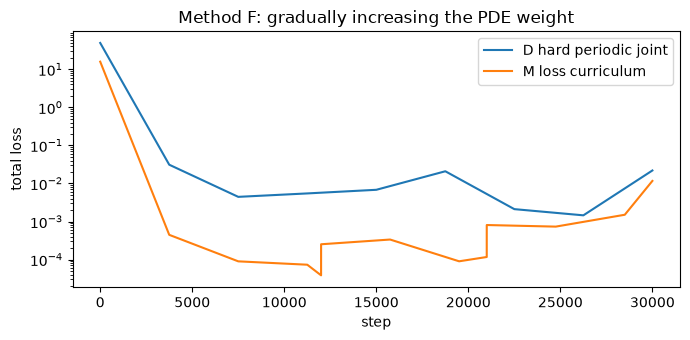

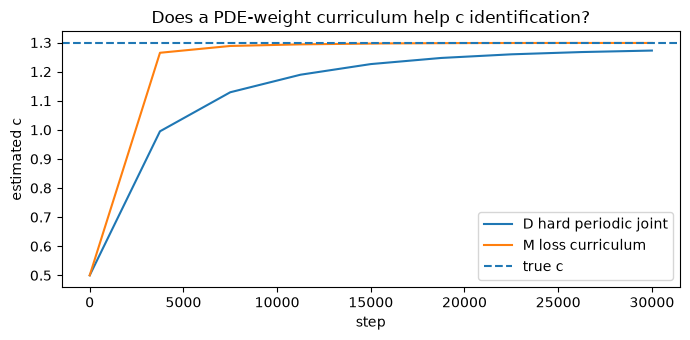


M. Loss curriculum
------------------
relative L2 error: 0.0059 -> good: the solution is learned reasonably well.
c_est: 1.298700, c_true: 1.300000, |error|=0.0013 -> good: c is accurately identified.
boundary MSE: 6.859e-14
held-out PDE residual MSE: 3.067e-02


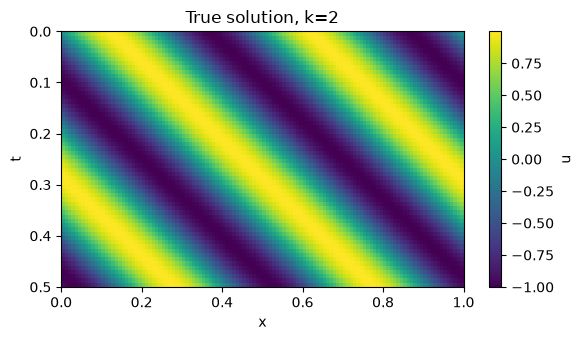

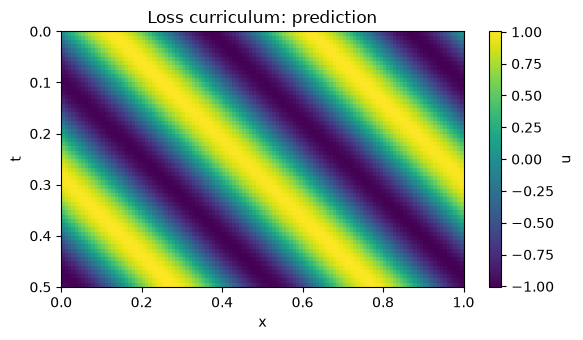

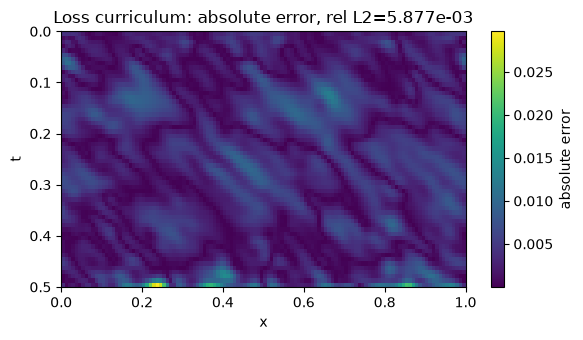

In [24]:
# Method F: loss curriculum for the PDE weight.
def train_loss_curriculum(
    model_name,
    seed=22,
    c_init=0.50,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    schedule=LOSS_CURRICULUM_SCHEDULE,
):
    state, _ = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)
    history = []
    global_step = 0

    for stage_name, weights, n_stage_steps in schedule:
        print(
            f"\n[{model_name}] stage: {stage_name}, "
            f"lambda_pde={weights['pde']}, steps={n_stage_steps}"
        )
        state, hist_stage = continue_train_pinn(
            model_name=f"{model_name}: {stage_name}",
            state=state,
            apply_fn=apply_fn,
            weights=weights,
            n_steps=n_stage_steps,
            lr_params=1e-3,
            lr_c=1e-3,
            current_batch=batch,
            step_offset=global_step,
        )
        history.extend(hist_stage)
        global_step += n_stage_steps

    return state, history

if RUN_LOSS_CURRICULUM_EXPERIMENT:
    print("\nMethod F: loss curriculum")
    loss_curriculum_state, loss_curriculum_hist = train_loss_curriculum(
        model_name="M loss curriculum"
    )
    loss_curriculum_h = history_to_arrays(loss_curriculum_hist)

    plt.figure(figsize=(7, 3.5))
    plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic joint")
    plt.semilogy(loss_curriculum_h["step"], loss_curriculum_h["total"], label="M loss curriculum")
    plt.xlabel("step")
    plt.ylabel("total loss")
    plt.title("Method F: gradually increasing the PDE weight")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(loss_curriculum_h["step"], loss_curriculum_h["c"], label="M loss curriculum")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Does a PDE-weight curriculum help c identification?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_curriculum_metrics = evaluate_on_grid(loss_curriculum_state, hard_periodic_apply)
    print_interpretation("M. Loss curriculum", loss_curriculum_metrics)
    add_result(RESULTS, "M loss curriculum", loss_curriculum_metrics, baseline=hard_metrics)
    plot_solution_comparison(loss_curriculum_metrics, "Loss curriculum")
else:
    print("Method F skipped. Set RUN_LOSS_CURRICULUM_EXPERIMENT=True to run it.")


### 14.2 Method G: Adaptive gradient-balanced loss weighting

The next retained method follows a common PINN idea: different loss components can have very different gradient scales. Instead of fixing all weights manually, we periodically rebalance the PDE, IC, BC and data weights using their gradient norms.

This is kept because it produced a learned value of $c$ close to the true value in the current $k=2$ run.



Method G: adaptive gradient-balanced loss weighting
[N adaptive gradient weights] reweight at step 1: lambda_pde=0.81, lambda_ic=9.15, lambda_data=11.1
[N adaptive gradient weights] step=    1 loss=1.247e+02 pde=1.35e+02 ic=8.45e-01 data=6.92e-01 c=0.500000
[N adaptive gradient weights] step= 3750 loss=1.694e-02 pde=7.92e-03 ic=9.15e-05 data=8.77e-04 c=1.173752
[N adaptive gradient weights] step= 7500 loss=2.387e-03 pde=1.14e-03 ic=1.33e-05 data=1.21e-04 c=1.249390
[N adaptive gradient weights] reweight at step 7501: lambda_pde=0.658, lambda_ic=9.91, lambda_data=10.4
[N adaptive gradient weights] step=11250 loss=6.260e-03 pde=8.44e-03 ic=1.51e-05 data=5.30e-05 c=1.271059
[N adaptive gradient weights] step=15000 loss=1.637e-03 pde=2.03e-03 ic=6.29e-06 data=2.32e-05 c=1.281607
[N adaptive gradient weights] reweight at step 15001: lambda_pde=0.536, lambda_ic=9.6, lambda_data=10.9
[N adaptive gradient weights] step=18750 loss=1.484e-03 pde=2.37e-03 ic=5.13e-06 data=1.50e-05 c=1.286791
[N 

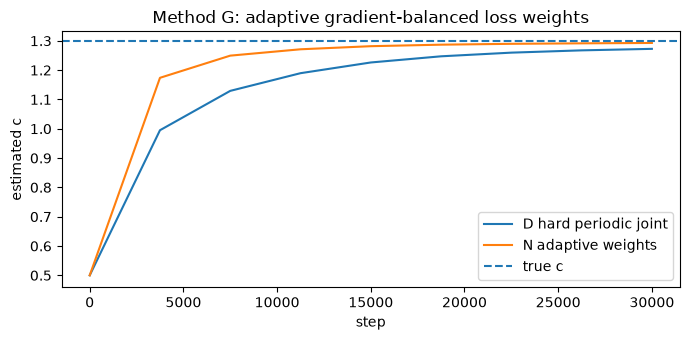

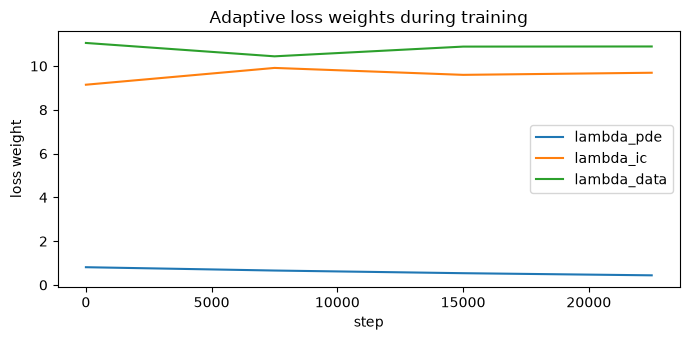


N. Adaptive gradient-balanced weighting
---------------------------------------
relative L2 error: 0.0075 -> good: the solution is learned reasonably well.
c_est: 1.292663, c_true: 1.300000, |error|=0.0073 -> good: c is accurately identified.
boundary MSE: 9.563e-14
held-out PDE residual MSE: 9.401e-02


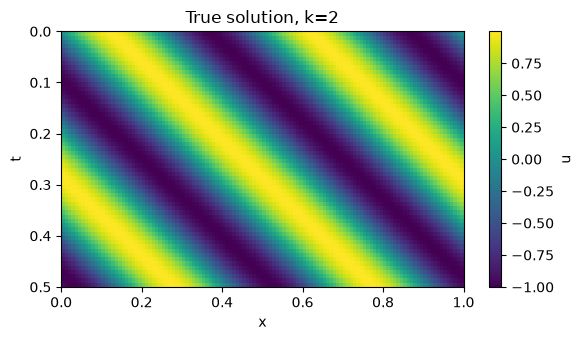

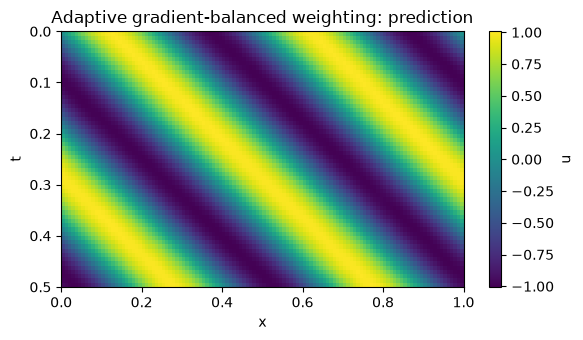

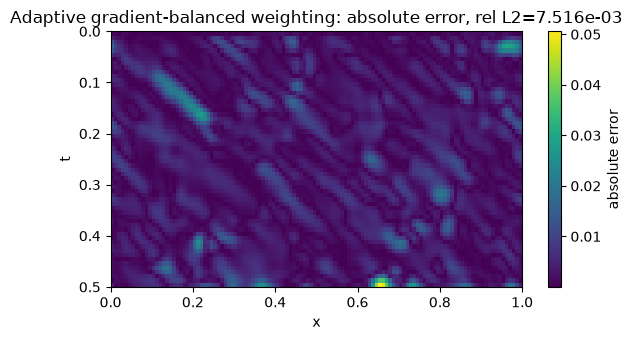

In [25]:

# Method G: adaptive gradient-balanced loss weighting.
#
# Motivation:
# In inverse PINNs, different loss components can have very different gradient scales.
# If the PDE residual becomes small too early while data/IC errors are still large,
# c may be trained using unreliable derivatives. This method periodically rebalances
# the loss weights using gradient norms with respect to the network parameters.
#
# Important:
# This is a simple and transparent implementation, not a full NTK adaptive weighting method.

def component_grad_norm_wrt_params(state, apply_fn, term, current_batch=batch):
    """Gradient norm of one unweighted loss component with respect to theta."""
    def component_loss_on_params(params):
        tmp_state = {"params": params, "raw_c": state["raw_c"]}
        return loss_parts(tmp_state, current_batch, apply_fn)[term]
    grad_params = jax.grad(component_loss_on_params)(state["params"])
    return float(tree_l2_norm(grad_params))

def update_gradient_balanced_weights(
    state,
    apply_fn,
    old_weights,
    base_weights=HARD_BC_WEIGHTS,
    current_batch=batch,
    smoothing=ADAPTIVE_WEIGHT_SMOOTHING,
    clip_range=ADAPTIVE_WEIGHT_CLIP,
):
    """Update weights so active loss terms have roughly comparable gradient norms."""
    active_terms = [k for k, v in base_weights.items() if v > 0.0]
    norms = {
        k: component_grad_norm_wrt_params(state, apply_fn, k, current_batch)
        for k in active_terms
    }

    # Use the average norm as the target. Terms with small gradients receive larger weights.
    target = float(np.mean([norms[k] for k in active_terms])) + ADAPTIVE_WEIGHT_EPS
    raw_weights = dict(base_weights)
    for k in active_terms:
        raw_weights[k] = base_weights[k] * target / (norms[k] + ADAPTIVE_WEIGHT_EPS)

    # Normalize so the total active weight stays comparable to the original scale.
    sum_base = sum(base_weights[k] for k in active_terms)
    sum_raw = sum(raw_weights[k] for k in active_terms)
    if sum_raw > 0:
        scale = sum_base / sum_raw
        for k in active_terms:
            raw_weights[k] *= scale

    lo, hi = clip_range
    new_weights = {}
    for k in base_weights.keys():
        if base_weights[k] == 0.0:
            new_weights[k] = 0.0
        else:
            proposed = float(np.clip(raw_weights[k], lo, hi))
            new_weights[k] = smoothing * float(old_weights[k]) + (1.0 - smoothing) * proposed

    return new_weights, norms

def train_adaptive_grad_weighting(
    model_name="N adaptive gradient weights",
    seed=23,
    c_init=0.50,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    base_weights=HARD_BC_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
    current_batch=batch,
):
    state, opt_state = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)
    weights = dict(base_weights)
    loss_fn = make_loss_fn(apply_fn, weights)
    train_step = make_train_step(loss_fn, lr_params, lr_c)

    history = []
    weight_history = []
    start = time.time()

    for step in range(1, n_steps + 1):
        if step == 1 or (step - 1) % ADAPTIVE_REWEIGHT_EVERY == 0:
            weights, norms = update_gradient_balanced_weights(
                state, apply_fn, weights, base_weights, current_batch
            )
            loss_fn = make_loss_fn(apply_fn, weights)
            train_step = make_train_step(loss_fn, lr_params, lr_c)
            weight_history.append({
                "step": step,
                "lambda_pde": weights["pde"],
                "lambda_ic": weights["ic"],
                "lambda_bc": weights["bc"],
                "lambda_data": weights["data"],
                "norm_pde": norms.get("pde", np.nan),
                "norm_ic": norms.get("ic", np.nan),
                "norm_bc": norms.get("bc", np.nan),
                "norm_data": norms.get("data", np.nan),
            })
            print(
                f"[{model_name}] reweight at step {step}: "
                f"lambda_pde={weights['pde']:.3g}, "
                f"lambda_ic={weights['ic']:.3g}, "
                f"lambda_data={weights['data']:.3g}"
            )

        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] step={step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] finished in {elapsed:.1f} seconds.")
    return state, history, weight_history

if RUN_ADAPTIVE_GRAD_WEIGHTING:
    print("\nMethod G: adaptive gradient-balanced loss weighting")
    adaptive_state, adaptive_hist, adaptive_weight_hist = train_adaptive_grad_weighting()
    adaptive_h = history_to_arrays(adaptive_hist)

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(adaptive_h["step"], adaptive_h["c"], label="N adaptive weights")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method G: adaptive gradient-balanced loss weights")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(adaptive_weight_hist) > 0:
        wh = {k: np.array([r[k] for r in adaptive_weight_hist]) for k in adaptive_weight_hist[0].keys()}
        plt.figure(figsize=(7, 3.5))
        plt.plot(wh["step"], wh["lambda_pde"], label="lambda_pde")
        plt.plot(wh["step"], wh["lambda_ic"], label="lambda_ic")
        plt.plot(wh["step"], wh["lambda_data"], label="lambda_data")
        plt.xlabel("step")
        plt.ylabel("loss weight")
        plt.title("Adaptive loss weights during training")
        plt.legend()
        plt.tight_layout()
        plt.show()

    adaptive_metrics = evaluate_on_grid(adaptive_state, hard_periodic_apply)
    print_interpretation("N. Adaptive gradient-balanced weighting", adaptive_metrics)
    add_result(RESULTS, "N adaptive weights", adaptive_metrics, baseline=hard_metrics)
    plot_solution_comparison(adaptive_metrics, "Adaptive gradient-balanced weighting")
else:
    print("Method G skipped. Set RUN_ADAPTIVE_GRAD_WEIGHTING=True to run it.")


In [26]:

# Method I: residual-based adaptive refinement (RAR).
#
# RAR adds collocation points where the current PDE residual is large.
# This often helps forward PINN accuracy. In this inverse problem, it tests
# whether the wrong c is mainly caused by poor residual-point coverage.

def add_rar_points_to_batch(
    state,
    apply_fn,
    current_batch=batch,
    seed=202409,
    n_candidates=RAR_CANDIDATES,
    n_add=RAR_ADD,
):
    key = random.PRNGKey(seed)
    key_x, key_t = random.split(key)
    x_cand = random.uniform(key_x, (n_candidates, 1), minval=0.0, maxval=1.0)
    t_cand = random.uniform(key_t, (n_candidates, 1), minval=0.0, maxval=T_FINAL)
    xt_cand = jnp.concatenate([x_cand, t_cand], axis=1)

    res_abs = jnp.abs(pde_residual(state, xt_cand, apply_fn))
    top_idx = jnp.argsort(-res_abs)[: min(n_add, n_candidates)]
    xt_add = xt_cand[top_idx]

    new_batch = dict(current_batch)
    new_batch["xt_f"] = jnp.concatenate([current_batch["xt_f"], xt_add], axis=0)
    return new_batch, xt_add, res_abs[top_idx]

def train_rar_experiment(
    model_name="P RAR hard-periodic PINN",
    seed=25,
    c_init=0.50,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    weights=HARD_BC_WEIGHTS,
):
    state, _ = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)

    print(f"\n[{model_name}] stage 1: train on original collocation points")
    state, hist1 = continue_train_pinn(
        model_name=f"{model_name} pre-RAR",
        state=state,
        apply_fn=apply_fn,
        weights=weights,
        n_steps=RAR_PRETRAIN_STEPS,
        lr_params=1e-3,
        lr_c=1e-3,
        current_batch=batch,
        step_offset=0,
    )

    print(f"\n[{model_name}] select new residual points")
    rar_batch, xt_add, res_top = add_rar_points_to_batch(state, apply_fn, batch)
    print("  original N_F:", batch["xt_f"].shape[0])
    print("  added RAR points:", xt_add.shape[0])
    print("  new N_F:", rar_batch["xt_f"].shape[0])
    print("  largest selected residual:", float(jnp.max(res_top)))

    plt.figure(figsize=(5, 4))
    plt.scatter(np.array(batch["xt_f"][:, 0]), np.array(batch["xt_f"][:, 1]), s=8, alpha=0.35, label="original residual points")
    plt.scatter(np.array(xt_add[:, 0]), np.array(xt_add[:, 1]), s=12, label="RAR added points")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("RAR: added collocation points")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n[{model_name}] stage 2: continue training after RAR")
    state, hist2 = continue_train_pinn(
        model_name=f"{model_name} post-RAR",
        state=state,
        apply_fn=apply_fn,
        weights=weights,
        n_steps=RAR_FINETUNE_STEPS,
        lr_params=1e-3,
        lr_c=1e-3,
        current_batch=rar_batch,
        step_offset=RAR_PRETRAIN_STEPS,
    )

    return state, hist1 + hist2

if RUN_RAR_EXPERIMENT:
    print("\nMethod I: residual-based adaptive refinement")
    rar_state, rar_hist = train_rar_experiment()
    rar_h = history_to_arrays(rar_hist)

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(rar_h["step"], rar_h["c"], label="P RAR")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method I: does RAR help identify c?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    rar_metrics = evaluate_on_grid(rar_state, hard_periodic_apply)
    print_interpretation("P. Residual-based adaptive refinement", rar_metrics)
    add_result(RESULTS, "P RAR", rar_metrics, baseline=hard_metrics)
    plot_solution_comparison(rar_metrics, "Residual-based adaptive refinement")
else:
    print("Method I skipped. Set RUN_RAR_EXPERIMENT=True to run it.")


Method I skipped. Set RUN_RAR_EXPERIMENT=True to run it.


### 14.4 How to interpret the retained experiments

These retained methods answer different diagnostic questions:

- If **loss curriculum** improves $c$, then early PDE-loss weighting maybe part of the problem.
- If **adaptive gradient-balanced weighting** improves $c$, then fixed manual weights were causing gradient imbalance between PDE, IC, BC and data terms.
- If **RAR** improves $c$, then collocation-point placement was a major bottleneck. If it only improves residual error but not $c$, then point placement is not the main cause of inverse-parameter failure.


## 15. Characteristic Loss Landscape and Learned Parameters

Here we mark the final values of $c$ obtained by different PINN methods on the same characteristic loss landscape.

Mathematically, we fix the data $(x_i,t_i,u_i)$ and treat only $c$ as the variable:

$$
L_{\mathrm{char}}(c)
=
\frac1N\sum_i
\left|
\sin(2\pi k(x_i-c t_i))-u_i
\right|^2.
$$

The key interpretation of this plot is: if the $c$ values from the standard or hard-periodic methods fall far from the true value, while grid-initialized two-stage training lands near the true value, then the central difficulty of the inverse problem is the nonconvexity and phase ambiguity of the $c$-landscape.


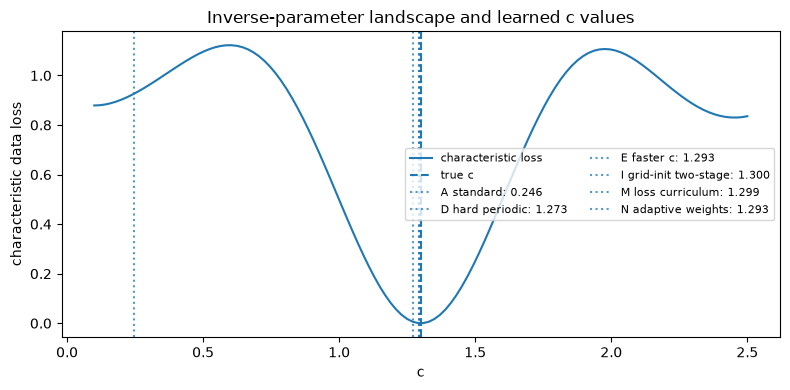

In [27]:
def plot_characteristic_landscape_with_estimates():
    plt.figure(figsize=(8, 4))
    plt.plot(np.array(c_grid_coarse), np.array(loss_grid_coarse), label="characteristic loss")
    plt.axvline(C_TRUE, linestyle="--", label="true c")

    estimates = [
        ("A standard", std_metrics["c_est"]),  # keep the baseline even if its estimate is below 1
        ("D hard periodic", hard_metrics["c_est"]),
        ("E faster c", hard_fastc_metrics["c_est"]),
    ]
    if "grid_init_metrics" in globals():
        estimates.append(("I grid-init two-stage", grid_init_metrics["c_est"]))
    if "loss_curriculum_metrics" in globals():
        estimates.append(("M loss curriculum", loss_curriculum_metrics["c_est"]))
    if "adaptive_metrics" in globals():
        estimates.append(("N adaptive weights", adaptive_metrics["c_est"]))
    if "rar_metrics" in globals():
        estimates.append(("P RAR", rar_metrics["c_est"]))
    if "multistart_metrics" in globals():
        estimates.append(("multi-start", multistart_metrics["c_est"]))
    if "curriculum_metrics" in globals():
        estimates.append(("frequency curriculum", curriculum_metrics["c_est"]))

    for name, c_value in estimates:
        plt.axvline(c_value, linestyle=":", alpha=0.75, label=f"{name}: {c_value:.3f}")

    plt.xlabel("c")
    plt.ylabel("characteristic data loss")
    plt.title("Inverse-parameter landscape and learned c values")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_characteristic_landscape_with_estimates()



## 16. Final Conclusions

1. **This notebook is a lower-frequency ablation of the original high-frequency inverse PINN problem.** The only intended mathematical change is (k=2) instead of (k=8), while the true wave speed remains (c_{\mathrm{true}}=1.30).

2. **Reducing (k) weakens the phase-sensitivity of the inverse problem.** Since the exact solution contains the phase
   [
   2\pi k(x-ct),
   ]
   the same error in (c) produces a four-times smaller phase error when moving from (k=8) to (k=2). Therefore, the (k=2) case is expected to be easier than the original high-frequency case.

3. **The standard joint PINN is retained as the failure baseline.** In the current run, the standard PINN estimates (c\approx 0.246), far from (c_{\mathrm{true}}=1.30). This shows that even in the lower-frequency setting, vanilla joint optimization can still converge to a wrong inverse-parameter basin.

4. **The characteristic-loss landscape explains why some methods succeed.** The retained successful methods produce estimated (c) values close to the minimum of the characteristic data loss near (c=1.30). In particular, hard periodic embedding, faster (c)-learning, grid-initialized two-stage training, loss curriculum, and adaptive gradient-balanced weighting all move (c) close to the correct basin.

5. **Grid initialization remains the most reliable inverse-specific reference method.** It directly uses the characteristic structure (u(x,t)=u_0(x-ct)) to locate a good initial value for (c), and then fine-tunes the PINN. This explains why it recovers (c\approx 1.300).

6. **Loss curriculum and adaptive weighting show that training dynamics matter.** Their success suggests that the failure of vanilla PINN is not only due to insufficient representation power. A major issue is the early optimization dynamics: the PDE residual can give weak or misleading gradients for (c) before the network has learned accurate derivatives.

7. **The retained experiments separate different possible failure causes.** Fourier features and hard periodic embedding test representation and boundary-condition effects. Loss curriculum tests early PDE-loss dominance. Adaptive weighting tests gradient imbalance. RAR is kept as an optional diagnostic for residual-point placement. 

8. **Overall, the (k=2) results support the main interpretation.** The inverse parameter (c) is identifiable, but vanilla joint PINN training is not always reliable. Successful recovery requires either placing (c) in a good characteristic basin or improving the training dynamics so that the gradient information for (c) becomes useful.



## 17. References and Corresponding Ideas

1. **Physics-informed neural networks**  
   M. Raissi, P. Perdikaris, and G. E. Karniadakis, *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*, Journal of Computational Physics, 2019.  
   Used to support the PINN loss and the inverse-parameter training framework.

2. **Neural Tangent Kernel**  
   A. Jacot, F. Gabriel, and C. Hongler, *Neural Tangent Kernel: Convergence and Generalization in Neural Networks*, NeurIPS, 2018.  
   Used to support the diagnostic idea of the empirical output NTK and the PDE residual NTK.

3. **Fourier features**  
   M. Tancik et al., *Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains*, NeurIPS, 2020.  
   Used to explain why sine/cosine input features can improve the representation of oscillatory functions. In this $k=2$ notebook, Fourier features are kept mainly as a control experiment.

4. **Gradient pathologies and adaptive loss balancing in PINNs**  
   S. Wang, Y. Teng, and P. Perdikaris, *Understanding and mitigating gradient flow pathologies in physics-informed neural networks*, SIAM Journal on Scientific Computing, 2021.  
   R. Bischof and M. A. Kraus, *Multi-Objective Loss Balancing for Physics-Informed Deep Learning*, 2021.  
   Used to motivate gradient-norm diagnosis and the adaptive loss-weighting experiment.

5. **Advection--diffusion / transport inverse PINNs**  
   Examples in the recent PINN literature often solve advection--diffusion, advection--dispersion--reaction, or transport inverse problems by combining observation loss, PDE residual loss, adaptive weighting, gradient scaling, Adam--L-BFGS training, or improved collocation strategies.  
   These papers motivate the adaptive weighting and RAR tests. The present notebook differs because it studies a pure advection equation where the unknown speed $c$ controls the phase $x-ct$. This $k=2$ version is a lower-frequency comparison to the harder $k=8$ case.

6. **Characteristic structure of the advection equation**  
   The identity $u(x,t;c)=u_0(x-ct)$ motivates the characteristic grid initialization used by the main two-stage method. This is a problem-specific inverse-parameter initialization rather than a generic PINN trick.
